In [1]:
# ============================================================
# VisionServeAI | Sprint 03
# Setup: Imports
# ============================================================

from __future__ import annotations

import json
import logging
import os
import random
import re
import sys
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore")

print("Python         :", sys.version.split()[0])
print("NumPy          :", np.__version__)
print("Pandas         :", pd.__version__)
print("Pillow         :", Image.__version__)
print()
print("Imports OK.")


Python         : 3.12.13
NumPy          : 2.4.6
Pandas         : 2.3.3
Pillow         : 11.3.0

Imports OK.


In [2]:
# ============================================================
# VisionServeAI | Sprint 03
# Setup: Logging
# ============================================================

LOG_FORMAT = "%(asctime)s | %(levelname)-8s | %(name)s | %(message)s"
LOG_DATE_FORMAT = "%Y-%m-%d %H:%M:%S"

logging.basicConfig(
    level=logging.INFO,
    format=LOG_FORMAT,
    datefmt=LOG_DATE_FORMAT,
    handlers=[logging.StreamHandler(sys.stdout)],
)

logger = logging.getLogger("visionserveai.sprint03")

logger.info("Logging configured. Level=INFO.")


2026-06-29 23:54:58 | INFO     | visionserveai.sprint03 | Logging configured. Level=INFO.


In [3]:
# ============================================================
# VisionServeAI | Sprint 03
# Setup: Random Seed
#
# Module: config.py → set_global_seed()
# ============================================================

RANDOM_SEED: int = 42


def set_global_seed(seed: int = RANDOM_SEED) -> None:
    """
    Set Python, NumPy, and (when available) PyTorch random seeds
    to guarantee cross-run reproducibility.

    Call once at pipeline construction time.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        logger.info("PyTorch seed set to %d.", seed)
    except ImportError:
        logger.info("PyTorch not available — skipping torch seed.")

    logger.info("Global random seed set to %d.", seed)


# ── Verification ────────────────────────────────────────────
set_global_seed(RANDOM_SEED)
print(f"Global seed : {RANDOM_SEED}")
print("Seed OK.")


2026-06-29 23:55:01 | INFO     | visionserveai.sprint03 | PyTorch seed set to 42.
2026-06-29 23:55:01 | INFO     | visionserveai.sprint03 | Global random seed set to 42.
Global seed : 42
Seed OK.


In [4]:
# ============================================================
# VisionServeAI | Sprint 03
# Setup: Shared Validation Utilities
#
# Module: config.py / utils.py
# ============================================================


def assert_row_count(df: pd.DataFrame, expected: int, label: str = "DataFrame") -> None:
    """Hard-fail if a DataFrame does not have the expected number of rows."""
    actual = len(df)
    if actual != expected:
        raise AssertionError(
            f"[{label}] Row count mismatch: expected {expected:,}, got {actual:,}."
        )
    logger.info("[%s] Row count OK: %d.", label, actual)


def assert_columns_present(
    df: pd.DataFrame, required: List[str], label: str = "DataFrame"
) -> None:
    """Hard-fail if any required column is missing from a DataFrame."""
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise AssertionError(
            f"[{label}] Missing columns: {missing}."
        )
    logger.info("[%s] Required columns present: %s.", label, required)


def assert_no_nulls(
    df: pd.DataFrame, columns: List[str], label: str = "DataFrame"
) -> None:
    """Hard-fail if any specified column contains null values."""
    for col in columns:
        null_count = df[col].isnull().sum()
        if null_count > 0:
            raise AssertionError(
                f"[{label}] Column '{col}' has {null_count:,} null values."
            )
    logger.info("[%s] No nulls in columns: %s.", label, columns)


def assert_unique(
    series: pd.Series, label: str = "Series"
) -> None:
    """Hard-fail if a Series contains duplicate values."""
    duplicates = series.duplicated().sum()
    if duplicates > 0:
        raise AssertionError(
            f"[{label}] Contains {duplicates:,} duplicate values."
        )
    logger.info("[%s] All values unique.", label)


def assert_positive(
    series: pd.Series, label: str = "Series"
) -> None:
    """Hard-fail if any value in a numeric Series is not strictly positive."""
    non_positive = (series <= 0).sum()
    if non_positive > 0:
        raise AssertionError(
            f"[{label}] Contains {non_positive:,} non-positive values."
        )
    logger.info("[%s] All values strictly positive.", label)


def assert_set_equal(
    actual: set,
    expected: set,
    label: str = "Set",
) -> None:
    """Hard-fail if two sets are not identical."""
    missing = expected - actual
    unexpected = actual - expected
    if missing or unexpected:
        raise AssertionError(
            f"[{label}] Set mismatch. "
            f"Missing: {sorted(missing)}. "
            f"Unexpected: {sorted(unexpected)}."
        )
    logger.info("[%s] Sets are identical (%d elements).", label, len(actual))


# ── Verification ────────────────────────────────────────────
print("Validation helpers defined:")
helpers = [
    "assert_row_count",
    "assert_columns_present",
    "assert_no_nulls",
    "assert_unique",
    "assert_positive",
    "assert_set_equal",
]
for h in helpers:
    print(f"  ✔  {h}")

print()
print("Shared utilities OK.")


Validation helpers defined:
  ✔  assert_row_count
  ✔  assert_columns_present
  ✔  assert_no_nulls
  ✔  assert_unique
  ✔  assert_positive
  ✔  assert_set_equal

Shared utilities OK.


In [5]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 1: Configuration
#
# Module: training/config.py → PipelineConfig
# ============================================================
from dataclasses import FrozenInstanceError


@dataclass(frozen=True)
class PipelineConfig:
    """
    Immutable, validated configuration for the VisionServeAI
    production data pipeline.

    All fields are type-annotated (required for @dataclass field
    registration) and validated at construction time via
    __post_init__.  frozen=True enforces write-once semantics —
    a FrozenInstanceError is raised on any attempted mutation.

    Migration note
    --------------
    This class maps directly to training/config.py.  The
    KAGGLE_INPUT_ROOT attribute accommodates the nested
    /kaggle/input/<dataset-slug>/... layout confirmed in Sprint 02;
    change only this one constant when moving to a different storage
    backend (cloud bucket, local NAS, etc.).
    """

    # ── Project ──────────────────────────────────────────────
    PROJECT_NAME: str = "VisionServeAI"
    SPRINT: str = "03"

    # ── Filesystem roots ─────────────────────────────────────
    # Sprint 02 verified that on Kaggle the dataset is mounted at:
    #   /kaggle/input/data/
    # and that images live in nested shards:
    #   /kaggle/input/data/images_NNN/images/*.png
    from pathlib import Path

    KAGGLE_INPUT = Path("/kaggle/input")

    candidate_roots = [
        p
        for p in KAGGLE_INPUT.rglob("Data_Entry_2017.csv")
    ]

    if len(candidate_roots) != 1:
        raise RuntimeError(
            "Unable to uniquely locate NIH ChestXray14 dataset."
        )
        
    DATA_ROOT: Path = candidate_roots[0].parent

    METADATA_FILE: Path = DATA_ROOT / "Data_Entry_2017.csv"

    BBOX_FILE: Path = DATA_ROOT / "BBox_List_2017.csv"

    TEST_LIST_FILE: Path = DATA_ROOT / "test_list.txt"

    TRAIN_VAL_LIST_FILE: Path = DATA_ROOT / "train_val_list.txt"

    # ── Image parameters ─────────────────────────────────────
    # 224x224 is the canonical input size for the Phase 1 backbones
    # (DenseNet121, ConvNeXt, EfficientNet, ViT).
    IMAGE_SIZE: Tuple[int, int] = (224, 224)

    # ── Dataset constants (Sprint 02–verified) ───────────────
    NUM_CLASSES: int = 14
    TOTAL_IMAGES: int = 112_120        # Hard-verified in Sprint 02
    TOTAL_PATIENTS: int = 30_805       # Hard-verified in Sprint 02

    # ── Split ratios (train_val pool only; test comes from NIH) ─
    # Sprint 03 spec §7.1: test = NIH test_list.txt (fixed);
    # train_val pool split 80/20 (train/val), patient-stratified.
    TRAIN_RATIO: float = 0.80
    VAL_RATIO: float = 0.20

    # ── Reproducibility ──────────────────────────────────────
    RANDOM_SEED: int = RANDOM_SEED     # Re-uses the module-level constant

    # ── DataLoader defaults ──────────────────────────────────
    BATCH_SIZE: int = 32
    NUM_WORKERS: int = 2

    # ── Artifact versioning ──────────────────────────────────
    SCHEMA_VERSION: str = "v1"

    # ── Output directory (persisted artifacts) ───────────────
    OUTPUT_DIR: Path = Path("/kaggle/working/visionserveai/sprint03")

    # ── Validation ───────────────────────────────────────────
    def __post_init__(self) -> None:
        """Validate field values at construction time."""
        if self.NUM_CLASSES != 14:
            raise ValueError(
                f"NUM_CLASSES must be 14 (the frozen NIH registry); got {self.NUM_CLASSES}."
            )
        if self.TOTAL_IMAGES != 112_120:
            raise ValueError(
                f"TOTAL_IMAGES must be 112,120 (Sprint 02-verified); "
                f"got {self.TOTAL_IMAGES}."
            )
        if not (0.0 < self.TRAIN_RATIO < 1.0):
            raise ValueError(f"TRAIN_RATIO must be in (0, 1); got {self.TRAIN_RATIO}.")
        if not (0.0 < self.VAL_RATIO < 1.0):
            raise ValueError(f"VAL_RATIO must be in (0, 1); got {self.VAL_RATIO}.")
        if abs(self.TRAIN_RATIO + self.VAL_RATIO - 1.0) > 1e-9:
            raise ValueError(
                f"TRAIN_RATIO + VAL_RATIO must equal 1.0; "
                f"got {self.TRAIN_RATIO + self.VAL_RATIO}."
            )
        if self.BATCH_SIZE < 1:
            raise ValueError(f"BATCH_SIZE must be >= 1; got {self.BATCH_SIZE}.")
        if self.IMAGE_SIZE[0] <= 0 or self.IMAGE_SIZE[1] <= 0:
            raise ValueError(f"IMAGE_SIZE dimensions must be positive; got {self.IMAGE_SIZE}.")

    def display(self) -> None:
        """Pretty-print configuration for notebook verification."""
        width = 70
        print("=" * width)
        print(f"  {self.PROJECT_NAME} | Sprint {self.SPRINT} | Pipeline Configuration")
        print("=" * width)
        for f_name, f_val in self.__dataclass_fields__.items():
            val = getattr(self, f_name)
            print(f"  {f_name:<30} {val}")
        print("=" * width)


# ── Construct the singleton configuration ───────────────────
cfg = PipelineConfig()

# Ensure output directory exists
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Verification ────────────────────────────────────────────
print()
cfg.display()
print()

# Confirm frozen=True is operative
try:
    cfg.NUM_CLASSES = 99
    raise AssertionError(
        "Frozen dataclass failed to prevent modification."
    )

except FrozenInstanceError:
    print("Immutability check  : PASSED")

print(
    f"Dataclass fields    : {len(cfg.__dataclass_fields__)} registered"
)

assert cfg.NUM_CLASSES == 14
assert cfg.TOTAL_IMAGES == 112_120
assert cfg.RANDOM_SEED == 42

print()
print("Stage 1 — Configuration : PASSED")



  VisionServeAI | Sprint 03 | Pipeline Configuration
  PROJECT_NAME                   VisionServeAI
  SPRINT                         03
  DATA_ROOT                      /kaggle/input/datasets/organizations/nih-chest-xrays/data
  METADATA_FILE                  /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
  BBOX_FILE                      /kaggle/input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv
  TEST_LIST_FILE                 /kaggle/input/datasets/organizations/nih-chest-xrays/data/test_list.txt
  TRAIN_VAL_LIST_FILE            /kaggle/input/datasets/organizations/nih-chest-xrays/data/train_val_list.txt
  IMAGE_SIZE                     (224, 224)
  NUM_CLASSES                    14
  TOTAL_IMAGES                   112120
  TOTAL_PATIENTS                 30805
  TRAIN_RATIO                    0.8
  VAL_RATIO                      0.2
  RANDOM_SEED                    42
  BATCH_SIZE                     32
  NUM_WORKERS                  

In [6]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 2: Metadata
#
# Module: training/metadata.py
# ============================================================

# ── Constants ───────────────────────────────────────────────

# Raw column names exactly as they appear in Data_Entry_2017.csv.
# Validated BEFORE any cleaning — a mismatch means the on-disk
# dataset version has drifted from what this pipeline was built for.
_RAW_COLUMNS_EXPECTED: List[str] = [
    "Image Index",
    "Finding Labels",
    "Follow-up #",
    "Patient ID",
    "Patient Age",
    "Patient Gender",
    "View Position",
    "OriginalImage[Width",
    "Height]",
    "OriginalImagePixelSpacing[x",
    "y]",
    "Unnamed: 11",
]

# Rename map: raw NIH name → canonical snake_case name.
_COLUMN_RENAME_MAP: Dict[str, str] = {
    "Image Index":                    "image_index",
    "Finding Labels":                 "finding_labels",
    "Follow-up #":                    "follow_up_number",
    "Patient ID":                     "patient_id",
    "Patient Age":                    "patient_age",
    "Patient Gender":                 "patient_gender",
    "View Position":                  "view_position",
    "OriginalImage[Width":            "original_image_width",
    "Height]":                        "original_image_height",
    "OriginalImagePixelSpacing[x":    "original_pixel_spacing_x",
    "y]":                             "original_pixel_spacing_y",
}

# Canonical post-clean column list (Unnamed:11 already dropped).
CANONICAL_COLUMNS: List[str] = [
    "image_index",
    "finding_labels",
    "follow_up_number",
    "patient_id",
    "patient_age",
    "patient_gender",
    "view_position",
    "original_image_width",
    "original_image_height",
    "original_pixel_spacing_x",
    "original_pixel_spacing_y",
]

# Filename pattern validated in Sprint 02 §3.
_IMAGE_FILENAME_PATTERN: re.Pattern = re.compile(r"^\d{8}_\d{3}\.png$")


def load_raw_metadata(path: Path) -> pd.DataFrame:
    """
    Load the raw NIH metadata CSV without any transformation.
    Validates that the expected 12 raw columns are present and
    that the row count matches the Sprint 02-verified total.
    """
    logger.info("Loading raw metadata from: %s", path)
    df = pd.read_csv(path)
    logger.info("Raw metadata shape: %s.", df.shape)

    # Pre-cleaning schema validation — raw names, not canonical ones.
    assert_columns_present(df, _RAW_COLUMNS_EXPECTED, label="RawMetadata")
    assert_row_count(df, cfg.TOTAL_IMAGES, label="RawMetadata")

    return df


def clean_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply documented cleaning rules to raw metadata:
      1. Drop Unnamed: 11 (100% null, zero information content).
      2. Rename all columns to canonical snake_case names.

    Returns a new DataFrame; never mutates the input.
    """
    result = df.copy()

    # Step 1 — Drop the null sentinel column.
    result = result.drop(columns=["Unnamed: 11"])
    logger.info("Dropped 'Unnamed: 11'.")

    # Step 2 — Rename to canonical names.
    result = result.rename(columns=_COLUMN_RENAME_MAP)
    logger.info("Columns renamed to canonical schema.")

    return result


def validate_metadata(df: pd.DataFrame) -> None:
    """
    Validate canonical metadata against the full Sprint 03 spec §4.2
    rule set.  Raises AssertionError on any failure — the pipeline
    never continues past a failing validation.
    """
    # Column names
    assert_columns_present(df, CANONICAL_COLUMNS, label="CanonicalMetadata")

    # Row count (hard gate — Sprint 02-verified figure)
    assert_row_count(df, cfg.TOTAL_IMAGES, label="CanonicalMetadata")

    # Uniqueness
    assert_unique(df["image_index"], label="image_index")

    # No nulls in required columns
    assert_no_nulls(
        df,
        ["image_index", "finding_labels", "patient_id"],
        label="CanonicalMetadata",
    )

    # Positive image dimensions
    assert_positive(df["original_image_width"],  label="original_image_width")
    assert_positive(df["original_image_height"], label="original_image_height")

    # Patient ID must be a positive integer
    assert_positive(df["patient_id"].astype(float), label="patient_id")

    # Filename pattern check (subset sample for speed; full check at manifest stage)
    sample_names = df["image_index"].sample(1000, random_state=cfg.RANDOM_SEED)
    bad_names = [n for n in sample_names if not _IMAGE_FILENAME_PATTERN.match(str(n))]
    if bad_names:
        raise AssertionError(
            f"image_index contains filenames not matching expected pattern. "
            f"Examples: {bad_names[:5]}"
        )
    logger.info("Filename pattern check passed on 1,000-row sample.")

    # Finding labels must be non-empty strings
    empty_labels = (df["finding_labels"].str.strip() == "").sum()
    if empty_labels > 0:
        raise AssertionError(
            f"finding_labels contains {empty_labels:,} empty strings."
        )
    logger.info("Finding labels non-empty check passed.")

    logger.info(
        "Metadata validation complete. Rows=%d, Patients=%d, LabelCombinations=%d.",
        len(df),
        df["patient_id"].nunique(),
        df["finding_labels"].nunique(),
    )


def build_image_shard_roots(data_root: Path) -> List[Path]:
    """
    Discover all images_NNN/images/ directories under data_root.

    Sprint 02 confirmed the nested layout:
        data_root/images_NNN/images/*.png

    Returns paths sorted lexicographically for deterministic ordering.
    """
    shard_dirs = sorted(data_root.glob("images_*/images"))
    logger.info(
        "Discovered %d image shard roots under %s.", len(shard_dirs), data_root
    )
    return shard_dirs


In [7]:
# ── Execute Stage 2 ──────────────────────────────────────────
print("=" * 70)
print("STAGE 2 — METADATA PIPELINE")
print("=" * 70)

# Load raw metadata
raw_metadata = load_raw_metadata(cfg.METADATA_FILE)

print(f"\nRaw columns ({len(raw_metadata.columns)}):")
for col in raw_metadata.columns:
    print(f"  {col!r}")

# Clean
metadata = clean_metadata(raw_metadata)

print(f"\nCanonical columns ({len(metadata.columns)}):")
for col in metadata.columns:
    print(f"  {col!r}")

# Validate
validate_metadata(metadata)

# Discover image shard roots
IMAGE_SHARD_ROOTS: List[Path] = build_image_shard_roots(cfg.DATA_ROOT)

print("\n" + "=" * 70)
print("METADATA VALIDATION SUMMARY")
print("=" * 70)
print(f"  Total rows       : {len(metadata):,}")
print(f"  Total patients   : {metadata['patient_id'].nunique():,}")
print(f"  Label combos     : {metadata['finding_labels'].nunique():,}")
print(f"  Image shards     : {len(IMAGE_SHARD_ROOTS)}")
print(f"  Width range      : {metadata['original_image_width'].min()}–{metadata['original_image_width'].max()}")
print(f"  Height range     : {metadata['original_image_height'].min()}–{metadata['original_image_height'].max()}")
print()
print("Stage 2 — Metadata : OK")


STAGE 2 — METADATA PIPELINE
2026-06-29 23:58:34 | INFO     | visionserveai.sprint03 | Loading raw metadata from: /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
2026-06-29 23:58:34 | INFO     | visionserveai.sprint03 | Raw metadata shape: (112120, 12).
2026-06-29 23:58:34 | INFO     | visionserveai.sprint03 | [RawMetadata] Required columns present: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11'].
2026-06-29 23:58:34 | INFO     | visionserveai.sprint03 | [RawMetadata] Row count OK: 112120.

Raw columns (12):
  'Image Index'
  'Finding Labels'
  'Follow-up #'
  'Patient ID'
  'Patient Age'
  'Patient Gender'
  'View Position'
  'OriginalImage[Width'
  'Height]'
  'OriginalImagePixelSpacing[x'
  'y]'
  'Unnamed: 11'
2026-06-29 23:58:34 | INFO     | visionserveai.sprint03 | Dropped 'Unnamed: 11'.
2026-06-29 23:5

In [8]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 3: Disease Registry
#
# Module: training/registry.py
# ============================================================

# ── Frozen canonical registry ────────────────────────────────
# Alphabetical ordering, exactly as verified in Sprint 02 §8.3.
# This list is NEVER dynamically re-derived — it is the frozen
# ground truth from which all encoding/decoding is derived.

CANONICAL_DISEASES: Tuple[str, ...] = (
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax",
)

# Immutable index mappings derived once from the canonical list.
DISEASE_TO_INDEX: Dict[str, int] = {
    disease: idx for idx, disease in enumerate(CANONICAL_DISEASES)
}

INDEX_TO_DISEASE: Dict[int, str] = {
    idx: disease for idx, disease in enumerate(CANONICAL_DISEASES)
}


def get_registry_summary() -> Dict[str, Any]:
    """
    Return a serialisation-ready dict representing the frozen registry.
    Used for persistence to disease_registry_v1.json.
    """
    return {
        "schema_version": cfg.SCHEMA_VERSION,
        "num_classes": len(CANONICAL_DISEASES),
        "no_finding_note": (
            "'No Finding' is NOT assigned an index. "
            "It is the derived absence of all 14 positive classes (Phase 1 §2)."
        ),
        "diseases": list(CANONICAL_DISEASES),
        "disease_to_index": DISEASE_TO_INDEX,
        "index_to_disease": {str(k): v for k, v in INDEX_TO_DISEASE.items()},
    }


def validate_registry(metadata_df: pd.DataFrame) -> None:
    """
    Regression check: discover every unique non-'No Finding' token
    in the metadata's finding_labels column and assert the result
    equals exactly the 14 canonical diseases — no more, no fewer.

    A mismatch means the on-disk dataset has changed since Sprint 02
    (a new disease token appeared, or a known one is absent).
    This is a hard failure — the pipeline never continues.
    """
    logger.info("Discovering disease tokens from metadata for registry regression check...")

    observed: set = set()
    for label_str in metadata_df["finding_labels"]:
        if label_str == "No Finding":
            continue
        observed.update(label_str.split("|"))

    assert_set_equal(observed, set(CANONICAL_DISEASES), label="DiseaseRegistry")
    logger.info("Registry regression check passed. Observed %d diseases.", len(observed))


def persist_registry(output_dir: Path) -> Path:
    """
    Write disease_registry_v1.json to the output directory.
    Returns the path of the written file.
    """
    path = output_dir / "disease_registry_v1.json"
    with open(path, "w") as f:
        json.dump(get_registry_summary(), f, indent=2)
    logger.info("Registry persisted to: %s", path)
    return path


In [9]:
# ── Execute Stage 3 ──────────────────────────────────────────
print("=" * 70)
print("STAGE 3 — CANONICAL DISEASE REGISTRY")
print("=" * 70)

# Structural validation
assert len(CANONICAL_DISEASES) == cfg.NUM_CLASSES, (
    f"Expected {cfg.NUM_CLASSES} diseases; got {len(CANONICAL_DISEASES)}."
)
assert len(DISEASE_TO_INDEX) == cfg.NUM_CLASSES
assert len(INDEX_TO_DISEASE) == cfg.NUM_CLASSES
assert set(DISEASE_TO_INDEX.keys()) == set(INDEX_TO_DISEASE.values())
assert "No Finding" not in DISEASE_TO_INDEX,     "'No Finding' must NOT be in the disease index — it is not a trained class."

# Regression check against metadata
validate_registry(metadata)

# Persist to disk
registry_path = persist_registry(cfg.OUTPUT_DIR)

# Display
print()
print(f"  Diseases : {len(CANONICAL_DISEASES)}")
print(f"  Registry file : {registry_path}")
print()
print(f"  {'Index':<6}  {'Disease'}")
print(f"  {'-'*6}  {'-'*20}")
for idx, disease in enumerate(CANONICAL_DISEASES):
    print(f"  {idx:<6}  {disease}")

print()

# Round-trip test on the persisted JSON
with open(registry_path) as f:
    loaded = json.load(f)

assert loaded["num_classes"] == cfg.NUM_CLASSES
assert loaded["diseases"] == list(CANONICAL_DISEASES)
assert loaded["schema_version"] == cfg.SCHEMA_VERSION
print(f"  Persisted JSON round-trip : OK (schema_version={loaded['schema_version']})")

print()
print("Stage 3 — Disease Registry : OK")


STAGE 3 — CANONICAL DISEASE REGISTRY
2026-06-29 23:58:35 | INFO     | visionserveai.sprint03 | Discovering disease tokens from metadata for registry regression check...
2026-06-29 23:58:35 | INFO     | visionserveai.sprint03 | [DiseaseRegistry] Sets are identical (14 elements).
2026-06-29 23:58:35 | INFO     | visionserveai.sprint03 | Registry regression check passed. Observed 14 diseases.
2026-06-29 23:58:35 | INFO     | visionserveai.sprint03 | Registry persisted to: /kaggle/working/visionserveai/sprint03/disease_registry_v1.json

  Diseases : 14
  Registry file : /kaggle/working/visionserveai/sprint03/disease_registry_v1.json

  Index   Disease
  ------  --------------------
  0       Atelectasis
  1       Cardiomegaly
  2       Consolidation
  3       Edema
  4       Effusion
  5       Emphysema
  6       Fibrosis
  7       Hernia
  8       Infiltration
  9       Mass
  10      Nodule
  11      Pleural_Thickening
  12      Pneumonia
  13      Pneumothorax

  Persisted JSON round-tr

In [10]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 4: Label Parser
#
# Module: training/labels.py → parse_labels()
# ============================================================

# Sentinel string that signals the absence of all 14 diseases.
NO_FINDING_SENTINEL: str = "No Finding"


def parse_labels(finding_labels_str: Any) -> List[str]:
    """
    Convert a raw NIH `finding_labels` string into a sorted,
    deduplicated list of validated disease names.

    Parameters
    ----------
    finding_labels_str : str
        A raw value from the ``finding_labels`` column, e.g.
        ``"Mass|Effusion"`` or ``"No Finding"``.

    Returns
    -------
    List[str]
        Sorted list of disease names.  Empty list for 'No Finding'.

    Raises
    ------
    ValueError
        If ``finding_labels_str`` is null/empty.
    ValueError
        If any token is not present in the frozen registry (spec §6.4).
    """
    # Hard failure: null / NaN / empty string
    if finding_labels_str is None or (
        isinstance(finding_labels_str, float) and np.isnan(finding_labels_str)
    ):
        raise ValueError(
            "finding_labels_str is null — "
            "metadata validation should have caught this upstream."
        )
    if not isinstance(finding_labels_str, str) or not finding_labels_str.strip():
        raise ValueError(
            f"finding_labels_str is empty or not a string: {finding_labels_str!r}"
        )

    # 'No Finding' → all-zero vector upstream (spec §6.1)
    if finding_labels_str == NO_FINDING_SENTINEL:
        return []

    # Split, deduplicate (set semantics), validate each token
    tokens = set(finding_labels_str.split("|"))
    unknown = tokens - set(CANONICAL_DISEASES)
    if unknown:
        raise ValueError(
            f"Unknown disease token(s) not in frozen registry: {sorted(unknown)}. "
            f"This indicates the dataset has changed since Sprint 02 — "
            f"pipeline halted to prevent silent label corruption."
        )

    return sorted(tokens)


In [11]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 4: Label Parser — Unit Tests
# ============================================================

def _run_parser_tests() -> None:
    """
    Unit test suite for parse_labels().
    Every test case either asserts the expected return value or
    asserts that the expected exception is raised.
    All tests are run in one call — a single failure raises immediately.
    """
    failures: List[str] = []

    def _check(description: str, actual: Any, expected: Any) -> None:
        if actual != expected:
            failures.append(
                f"FAIL [{description}]: expected {expected!r}, got {actual!r}"
            )
        else:
            print(f"  PASS  {description}")

    def _check_raises(description: str, fn: Callable, exc_type: type) -> None:
        try:
            fn()
            failures.append(f"FAIL [{description}]: expected {exc_type.__name__}, got no exception")
        except exc_type:
            print(f"  PASS  {description}")
        except Exception as e:
            failures.append(
                f"FAIL [{description}]: expected {exc_type.__name__}, got {type(e).__name__}: {e}"
            )

    print("Parser unit tests:")
    print("-" * 50)

    # 1. No Finding → empty list
    _check("'No Finding' → []", parse_labels("No Finding"), [])

    # 2. Single disease
    _check("'Mass' → ['Mass']", parse_labels("Mass"), ["Mass"])

    # 3. Multiple diseases (sorted)
    _check(
        "'Mass|Effusion' → ['Effusion', 'Mass']",
        parse_labels("Mass|Effusion"),
        ["Effusion", "Mass"],
    )

    # 4. Multiple diseases with ordering
    _check(
        "'Cardiomegaly|Edema|Mass' → sorted",
        parse_labels("Cardiomegaly|Edema|Mass"),
        ["Cardiomegaly", "Edema", "Mass"],
    )

    # 5. Duplicate tokens → deduplicated (set semantics)
    _check(
        "'Mass|Mass' → ['Mass'] (deduplication)",
        parse_labels("Mass|Mass"),
        ["Mass"],
    )

    # 6. All 14 diseases
    all_diseases_str = "|".join(CANONICAL_DISEASES)
    _check(
        "All 14 diseases → all 14 sorted",
        parse_labels(all_diseases_str),
        sorted(CANONICAL_DISEASES),
    )

    # 7. Unknown token → ValueError (hard failure)
    _check_raises(
        "Unknown token 'COVID19' → ValueError",
        lambda: parse_labels("COVID19"),
        ValueError,
    )

    # 8. Mixed known + unknown → ValueError
    _check_raises(
        "'Mass|UnknownDisease' → ValueError",
        lambda: parse_labels("Mass|UnknownDisease"),
        ValueError,
    )

    # 9. Null input → ValueError
    _check_raises(
        "None → ValueError",
        lambda: parse_labels(None),
        ValueError,
    )

    # 10. Empty string → ValueError
    _check_raises(
        "'' → ValueError",
        lambda: parse_labels(""),
        ValueError,
    )

    print("-" * 50)
    if failures:
        for f in failures:
            print(f)
        raise AssertionError(
            f"{len(failures)} parser unit test(s) failed. "
            "Pipeline halted — fix parse_labels before continuing."
        )

    print(f"  All tests passed.")


# ── Execute ──────────────────────────────────────────────────
print("=" * 70)
print("STAGE 4 — LABEL PARSER UNIT TESTS")
print("=" * 70)
print()
_run_parser_tests()
print()
print("Stage 4 — Label Parser : OK")


STAGE 4 — LABEL PARSER UNIT TESTS

Parser unit tests:
--------------------------------------------------
  PASS  'No Finding' → []
  PASS  'Mass' → ['Mass']
  PASS  'Mass|Effusion' → ['Effusion', 'Mass']
  PASS  'Cardiomegaly|Edema|Mass' → sorted
  PASS  'Mass|Mass' → ['Mass'] (deduplication)
  PASS  All 14 diseases → all 14 sorted
  PASS  Unknown token 'COVID19' → ValueError
  PASS  'Mass|UnknownDisease' → ValueError
  PASS  None → ValueError
  PASS  '' → ValueError
--------------------------------------------------
  All tests passed.

Stage 4 — Label Parser : OK


In [12]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 5: Label Encoder & Decoder
#
# Module: training/labels.py → encode_labels(), decode_labels()
# ============================================================


def encode_labels(finding_labels_str: str) -> np.ndarray:
    """
    Convert a raw NIH ``finding_labels`` string to a fixed-length
    14-dim multi-hot float32 vector.

    This is a pure function:
        encode_labels("Mass|Effusion")
        → array([0,0,0,0,1,0,0,0,0,1,0,0,0,0], dtype=float32)
                                  ^Effusion      ^Mass

    Parameters
    ----------
    finding_labels_str : str
        Raw value from the ``finding_labels`` column.

    Returns
    -------
    np.ndarray
        Shape (14,), dtype float32.  All zeros for 'No Finding'.

    Raises
    ------
    ValueError
        Propagated from parse_labels() for unknown tokens or null input.
    """
    vector = np.zeros(cfg.NUM_CLASSES, dtype=np.float32)

    for disease in parse_labels(finding_labels_str):
        vector[DISEASE_TO_INDEX[disease]] = 1.0

    return vector


def decode_labels(vector: np.ndarray) -> List[str]:
    """
    Convert a 14-dim multi-hot vector back to a sorted list of
    disease name strings.

    Parameters
    ----------
    vector : np.ndarray
        Shape (14,), values 0 or 1.  Float or integer dtypes accepted.

    Returns
    -------
    List[str]
        Sorted list of disease names.  Empty list for an all-zero vector
        (analogous to 'No Finding', but the caller formats the display).

    Raises
    ------
    IndexError
        If the vector length does not equal cfg.NUM_CLASSES.
    """
    if len(vector) != cfg.NUM_CLASSES:
        raise IndexError(
            f"Expected vector of length {cfg.NUM_CLASSES}; got {len(vector)}."
        )

    return sorted(
        INDEX_TO_DISEASE[idx]
        for idx, val in enumerate(vector)
        if val == 1
    )


In [13]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 5: Label Encoder/Decoder — Validation
# ============================================================

def _run_encoder_tests() -> None:
    """
    Unit tests for encode_labels() and decode_labels().
    Covers spec §6.5 requirements:
      - Every individual disease encodes to a vector with one set bit.
      - 'No Finding' encodes to all-zero.
      - Known multi-disease combinations round-trip correctly.
      - Unknown token raises ValueError.
      - Duplicate token does not corrupt the vector.
    """
    failures: List[str] = []

    def _check(desc: str, actual: Any, expected: Any) -> None:
        ok = (
            np.array_equal(actual, expected)
            if isinstance(actual, np.ndarray)
            else actual == expected
        )
        if not ok:
            failures.append(f"FAIL [{desc}]: expected {expected!r}, got {actual!r}")
        else:
            print(f"  PASS  {desc}")

    def _check_raises(desc: str, fn: Callable, exc_type: type) -> None:
        try:
            fn()
            failures.append(f"FAIL [{desc}]: expected {exc_type.__name__}, got no exception")
        except exc_type:
            print(f"  PASS  {desc}")
        except Exception as e:
            failures.append(
                f"FAIL [{desc}]: expected {exc_type.__name__}, "
                f"got {type(e).__name__}: {e}"
            )

    print("Encoder unit tests:")
    print("-" * 50)

    # 1. 'No Finding' → all-zero vector
    nf_vec = encode_labels("No Finding")
    _check("'No Finding' → all-zero vector", nf_vec.sum(), 0.0)
    _check("'No Finding' → dtype float32", nf_vec.dtype, np.float32)

    # 2. Each individual disease → exactly one set bit at its registry index
    for disease in CANONICAL_DISEASES:
        vec = encode_labels(disease)
        expected_idx = DISEASE_TO_INDEX[disease]
        _check(
            f"'{disease}' → bit at index {expected_idx}",
            int(vec[expected_idx]),
            1,
        )
        _check(
            f"'{disease}' → exactly 1 set bit total",
            int(vec.sum()),
            1,
        )

    # 3. Known multi-disease combination from Sprint 02 §8
    multi_vec = encode_labels("Cardiomegaly|Edema|Mass")
    _check("'Cardiomegaly|Edema|Mass' sum == 3", int(multi_vec.sum()), 3)
    _check("Cardiomegaly bit set", int(multi_vec[DISEASE_TO_INDEX["Cardiomegaly"]]), 1)
    _check("Edema bit set",        int(multi_vec[DISEASE_TO_INDEX["Edema"]]),        1)
    _check("Mass bit set",         int(multi_vec[DISEASE_TO_INDEX["Mass"]]),         1)

    # 4. Duplicate token → same as single (deduplication via parse_labels)
    dup_vec = encode_labels("Mass|Mass")
    _check("'Mass|Mass' → 1 set bit (dedup)", int(dup_vec.sum()), 1)

    # 5. Unknown token → ValueError
    _check_raises(
        "Unknown token → ValueError",
        lambda: encode_labels("COVID19"),
        ValueError,
    )

    print()
    print("Decoder unit tests:")
    print("-" * 50)

    # 6. All-zero vector → empty list
    zero_vec = np.zeros(cfg.NUM_CLASSES, dtype=np.float32)
    _check("all-zero vector → []", decode_labels(zero_vec), [])

    # 7. Decode the single-disease vectors
    for disease in CANONICAL_DISEASES:
        vec = encode_labels(disease)
        decoded = decode_labels(vec)
        _check(f"decode(encode('{disease}'))", decoded, [disease])

    # 8. Wrong-length vector → IndexError
    _check_raises(
        "Wrong-length vector → IndexError",
        lambda: decode_labels(np.zeros(5, dtype=np.float32)),
        IndexError,
    )

    print("-" * 50)
    if failures:
        for f in failures:
            print(f)
        raise AssertionError(
            f"{len(failures)} encoder/decoder unit test(s) failed. "
            "Pipeline halted."
        )
    print("  All tests passed.")


# Round-trip validation on a random sample of real metadata rows
def _run_roundtrip_validation(metadata_df: pd.DataFrame, n: int = 50) -> None:
    """
    For n randomly sampled finding_labels values from the real dataset,
    verify decode(encode(x)) == parse_labels(x).
    """
    sample = metadata_df["finding_labels"].sample(n, random_state=cfg.RANDOM_SEED)
    failures: List[str] = []

    for label_str in sample:
        encoded = encode_labels(label_str)
        decoded = sorted(decode_labels(encoded))
        expected = sorted(parse_labels(label_str))
        if decoded != expected:
            failures.append(
                f"Round-trip mismatch: input={label_str!r}, "
                f"decoded={decoded!r}, expected={expected!r}"
            )

    if failures:
        for f in failures:
            print(f"  FAIL  {f}")
        raise AssertionError(
            f"{len(failures)} round-trip failure(s) out of {n} samples. "
            "Pipeline halted."
        )

    logger.info("Round-trip validation passed on %d real metadata samples.", n)


# ── Execute ──────────────────────────────────────────────────
print("=" * 70)
print("STAGE 5 — LABEL ENCODER / DECODER")
print("=" * 70)
print()
_run_encoder_tests()
print()

# Round-trip on real data
print("Round-trip validation (50 real metadata samples):")
print("-" * 50)
_run_roundtrip_validation(metadata, n=50)
print("  PASS  All 50 round-trips correct.")
print()

# Quick display of example encodings
print("Example encodings:")
print(f"  {'Label string':<35}  {'Encoded vector (14-dim)'}")
print(f"  {'-'*35}  {'-'*40}")
examples = [
    "No Finding",
    "Mass",
    "Mass|Effusion",
    "Cardiomegaly|Edema|Mass",
    "Atelectasis|Infiltration|Nodule|Pneumonia",
]
for ex in examples:
    vec = encode_labels(ex)
    active = [f"{d}({i})" for i, d in enumerate(CANONICAL_DISEASES) if vec[i] == 1]
    print(f"  {ex:<35}  {active if active else '[No Finding]'}")

print()
print("Stage 5 — Label Encoder / Decoder : OK")


STAGE 5 — LABEL ENCODER / DECODER

Encoder unit tests:
--------------------------------------------------
  PASS  'No Finding' → all-zero vector
  PASS  'No Finding' → dtype float32
  PASS  'Atelectasis' → bit at index 0
  PASS  'Atelectasis' → exactly 1 set bit total
  PASS  'Cardiomegaly' → bit at index 1
  PASS  'Cardiomegaly' → exactly 1 set bit total
  PASS  'Consolidation' → bit at index 2
  PASS  'Consolidation' → exactly 1 set bit total
  PASS  'Edema' → bit at index 3
  PASS  'Edema' → exactly 1 set bit total
  PASS  'Effusion' → bit at index 4
  PASS  'Effusion' → exactly 1 set bit total
  PASS  'Emphysema' → bit at index 5
  PASS  'Emphysema' → exactly 1 set bit total
  PASS  'Fibrosis' → bit at index 6
  PASS  'Fibrosis' → exactly 1 set bit total
  PASS  'Hernia' → bit at index 7
  PASS  'Hernia' → exactly 1 set bit total
  PASS  'Infiltration' → bit at index 8
  PASS  'Infiltration' → exactly 1 set bit total
  PASS  'Mass' → bit at index 9
  PASS  'Mass' → exactly 1 set bi

In [14]:
print("encode_labels" in globals())
print("decode_labels" in globals())

True
True


In [15]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 6: Image Lookup Table (O(1))
#
# Module: training/manifest.py → build_image_lookup()
# ============================================================


def build_image_lookup(shard_roots: List[Path]) -> Dict[str, Path]:
    """
    Scan every image shard root exactly once and build a
    filename → absolute Path dictionary.

    Parameters
    ----------
    shard_roots : List[Path]
        Sorted list of shard root directories, each of the form
        /kaggle/input/data/images_NNN/images/

    Returns
    -------
    Dict[str, Path]
        Maps image filename (e.g. '00000001_000.png') → absolute Path.
        O(1) lookup at Dataset iteration time.

    Raises
    ------
    AssertionError
        If the resulting table size does not equal cfg.TOTAL_IMAGES
        (indicating a dataset-version drift since Sprint 02).
    AssertionError
        If any shard root does not exist on disk.
    """
    lookup: Dict[str, Path] = {}

    for shard_root in shard_roots:
        if not shard_root.exists():
            raise AssertionError(
                f"Image shard root not found: {shard_root}. "
                f"Verify the Kaggle dataset is attached."
            )
        for image_path in shard_root.glob("*.png"):
            lookup[image_path.name] = image_path

    logger.info(
        "Image lookup table built: %d images across %d shards.",
        len(lookup),
        len(shard_roots),
    )

    if len(lookup) != cfg.TOTAL_IMAGES:
        raise AssertionError(
            f"Image lookup table size mismatch: "
            f"expected {cfg.TOTAL_IMAGES:,}, found {len(lookup):,}. "
            f"Dataset version on disk may differ from Sprint 02-verified snapshot."
        )

    return lookup


In [16]:
# ── Execute Stage 6 ──────────────────────────────────────────
print("=" * 70)
print("STAGE 6 — IMAGE LOOKUP TABLE")
print("=" * 70)
print()

IMAGE_LOOKUP: Dict[str, Path] = build_image_lookup(IMAGE_SHARD_ROOTS)

# Verify every image_index in metadata resolves to a lookup entry
missing_from_lookup = metadata["image_index"][
    ~metadata["image_index"].isin(IMAGE_LOOKUP)
].tolist()

if missing_from_lookup:
    raise AssertionError(
        f"{len(missing_from_lookup):,} image_index values in metadata "
        f"have no corresponding file in the lookup table. "
        f"Examples: {missing_from_lookup[:5]}"
    )

# Spot-check 5 random entries to confirm paths resolve to real files
spot_check = (
    metadata["image_index"]
    .sample(5, random_state=cfg.RANDOM_SEED)
    .tolist()
)
for name in spot_check:
    path = IMAGE_LOOKUP[name]
    assert path.exists(), f"Spot-check file not found: {path}"
    assert path.name == name

print(f"  Total images indexed : {len(IMAGE_LOOKUP):,}")
print(f"  Metadata → Lookup    : {len(metadata):,} / {len(IMAGE_LOOKUP):,} matched")
print(f"  Missing from lookup  : {len(missing_from_lookup)}")
print()

print("  Spot-check (5 random entries):")
for name in spot_check:
    print(f"    {name}  →  {IMAGE_LOOKUP[name]}")

print()
print("Stage 6 — Image Lookup Table : OK")


STAGE 6 — IMAGE LOOKUP TABLE

2026-06-29 23:58:36 | INFO     | visionserveai.sprint03 | Image lookup table built: 112120 images across 12 shards.
  Total images indexed : 112,120
  Metadata → Lookup    : 112,120 / 112,120 matched
  Missing from lookup  : 0

  Spot-check (5 random entries):
    00022260_003.png  →  /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_010/images/00022260_003.png
    00012048_007.png  →  /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_006/images/00012048_007.png
    00014352_005.png  →  /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_007/images/00014352_005.png
    00006040_001.png  →  /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006040_001.png
    00011202_002.png  →  /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_005/images/00011202_002.png

Stage 6 — Image Lookup Table : OK


In [17]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 7: Manifest Construction
#
# Module: training/manifest.py → build_manifest()
# ============================================================


def build_manifest(
    metadata_df: pd.DataFrame,
    image_lookup: Dict[str, Path],
) -> pd.DataFrame:
    """
    Construct the canonical manifest DataFrame.

    Integrates:
      - Cleaned metadata (all canonical columns)
      - Resolved image paths from the O(1) lookup table
      - Parsed label lists (via parse_labels, not inline splitting)
      - Multi-hot encoded label vectors (via encode_labels)
      - Per-sample label count

    Parameters
    ----------
    metadata_df : pd.DataFrame
        Canonical, validated metadata produced by Stage 2.
    image_lookup : Dict[str, Path]
        O(1) filename → Path lookup table produced by Stage 6.

    Returns
    -------
    pd.DataFrame
        Manifest with all required and traceability columns.
        Row order matches metadata_df row order.

    Raises
    ------
    AssertionError
        If any image_index does not resolve to a lookup entry —
        this should never happen given Stage 6's coverage check,
        but the defensive guard remains.
    """
    manifest = metadata_df.copy()

    # ── Resolve image paths ──────────────────────────────────
    # Map image_index → absolute Path via the pre-built lookup.
    # No filesystem glob here — pure O(1) dict access.
    manifest["image_path"] = manifest["image_index"].map(image_lookup)

    unresolved = manifest["image_path"].isnull().sum()
    if unresolved > 0:
        bad = manifest[manifest["image_path"].isnull()]["image_index"].tolist()
        raise AssertionError(
            f"{unresolved:,} image_index values could not be resolved "
            f"to a file path. Examples: {bad[:5]}"
        )

    # ── Parse labels ─────────────────────────────────────────
    # Single canonical call to parse_labels — no inline splitting.
    manifest["parsed_labels"] = manifest["finding_labels"].apply(parse_labels)

    # ── Encode labels ────────────────────────────────────────
    # Multi-hot float32 numpy arrays, stored per row.
    manifest["encoded_labels"] = manifest["finding_labels"].apply(encode_labels)

    # ── Per-sample label count ───────────────────────────────
    manifest["num_labels"] = manifest["parsed_labels"].apply(len)

    logger.info(
        "Manifest built. Rows=%d, Columns=%d.",
        len(manifest),
        len(manifest.columns),
    )

    return manifest


In [18]:
# ============================================================
# VisionServeAI | Sprint 03
# Stage 7: Manifest Validation
#
# Module: training/manifest.py → validate_manifest()
# ============================================================


def validate_manifest(manifest_df: pd.DataFrame) -> None:
    """
    Validate the canonical manifest against the full Sprint 03
    spec §7 rule set.  Raises AssertionError on any failure.

    Checks
    ------
    1. Required columns present.
    2. Row count == cfg.TOTAL_IMAGES.
    3. image_index uniqueness.
    4. No nulls in required columns.
    5. Every image_path points to an existing file.
    6. encoded_labels shape and dtype correct for every row (sampled).
    7. parsed_labels is a list for every row.
    8. num_labels is non-negative for every row.
    9. Round-trip integrity: decode(encoded) == parsed for a sample.
    """
    REQUIRED_COLS = [
        "image_index",
        "image_path",
        "patient_id",
        "finding_labels",
        "parsed_labels",
        "encoded_labels",
        "num_labels",
    ]

    # 1 — Required columns
    assert_columns_present(manifest_df, REQUIRED_COLS, label="Manifest")

    # 2 — Row count
    assert_row_count(manifest_df, cfg.TOTAL_IMAGES, label="Manifest")

    # 3 — Uniqueness
    assert_unique(manifest_df["image_index"], label="Manifest.image_index")

    # 4 — No nulls in required columns
    assert_no_nulls(manifest_df, REQUIRED_COLS, label="Manifest")

    # 5 — File existence for all rows
    non_existent = manifest_df["image_path"].apply(lambda p: not p.exists()).sum()
    if non_existent > 0:
        raise AssertionError(
            f"Manifest contains {non_existent:,} rows whose image_path "
            f"does not point to an existing file."
        )
    logger.info("File existence check passed: all %d paths exist.", len(manifest_df))

    # 6 — encoded_labels shape and dtype (sampled 200 rows for speed)
    sample_indices = manifest_df.sample(
        min(200, len(manifest_df)), random_state=cfg.RANDOM_SEED
    ).index
    for idx in sample_indices:
        vec = manifest_df.at[idx, "encoded_labels"]
        if not isinstance(vec, np.ndarray):
            raise AssertionError(
                f"Row {idx}: encoded_labels is {type(vec).__name__}, not np.ndarray."
            )
        if vec.shape != (cfg.NUM_CLASSES,):
            raise AssertionError(
                f"Row {idx}: encoded_labels shape {vec.shape}, expected ({cfg.NUM_CLASSES},)."
            )
        if vec.dtype != np.float32:
            raise AssertionError(
                f"Row {idx}: encoded_labels dtype {vec.dtype}, expected float32."
            )
    logger.info("encoded_labels shape/dtype check passed on 200-row sample.")

    # 7 — parsed_labels is a list
    non_list = manifest_df["parsed_labels"].apply(lambda x: not isinstance(x, list)).sum()
    if non_list > 0:
        raise AssertionError(
            f"{non_list:,} rows have parsed_labels that is not a list."
        )

    # 8 — num_labels non-negative
    negative = (manifest_df["num_labels"] < 0).sum()
    if negative > 0:
        raise AssertionError(
            f"{negative:,} rows have num_labels < 0."
        )

    # 9 — Round-trip integrity on 100-row sample
    sample_rows = manifest_df.sample(100, random_state=cfg.RANDOM_SEED)
    rt_failures: List[str] = []
    for _, row in sample_rows.iterrows():
        decoded = sorted(decode_labels(row["encoded_labels"]))
        expected = sorted(row["parsed_labels"])
        if decoded != expected:
            rt_failures.append(
                f"image_index={row['image_index']!r}: "
                f"decoded={decoded!r}, expected={expected!r}"
            )
    if rt_failures:
        raise AssertionError(
            f"Round-trip validation failed for {len(rt_failures)} manifest rows. "
            f"First failure: {rt_failures[0]}"
        )
    logger.info("Round-trip integrity check passed on 100-row sample.")

    logger.info("Manifest validation complete. All checks passed.")


In [19]:
# ── Execute Stage 7 ──────────────────────────────────────────
print("=" * 70)
print("STAGE 7 — MANIFEST CONSTRUCTION")
print("=" * 70)
print()

manifest = build_manifest(metadata, IMAGE_LOOKUP)

print(f"  Shape            : {manifest.shape}")
print(f"  Columns          : {list(manifest.columns)}")
print()

print("=" * 70)
print("STAGE 7 — MANIFEST VALIDATION")
print("=" * 70)
print()

validate_manifest(manifest)

# ── Summary statistics ───────────────────────────────────────
total_images      = len(manifest)
total_patients    = manifest["patient_id"].nunique()
no_finding_count  = (manifest["num_labels"] == 0).sum()
multi_label_count = (manifest["num_labels"] > 1).sum()
mean_labels       = manifest["num_labels"].mean()
max_labels        = manifest["num_labels"].max()

print()
print("=" * 70)
print("MANIFEST SUMMARY")
print("=" * 70)
print(f"  Total images         : {total_images:,}")
print(f"  Total patients       : {total_patients:,}")
print(f"  'No Finding' rows    : {no_finding_count:,}  ({100*no_finding_count/total_images:.1f}%)")
print(f"  Multi-label rows     : {multi_label_count:,}  ({100*multi_label_count/total_images:.1f}%)")
print(f"  Mean labels/image    : {mean_labels:.3f}")
print(f"  Max labels/image     : {max_labels}")
print()

# Per-disease positive frequency (matches Sprint 02 §8.3 for regression)
print("  Per-disease positive frequency:")
print(f"    {'Disease':<25}  {'Count':>8}  {'% Images':>9}")
print(f"    {'-'*25}  {'-'*8}  {'-'*9}")
stacked = np.stack(manifest["encoded_labels"].values)
for idx, disease in enumerate(CANONICAL_DISEASES):
    count = int(stacked[:, idx].sum())
    pct   = 100.0 * count / total_images
    print(f"    {disease:<25}  {count:>8,}  {pct:>9.2f}%")

print()
print("Stage 7 — Manifest : OK")
print()
print("=" * 70)
print("CHAT 1 COMPLETE — Stages 1–7 (Setup → Manifest Validation)")
print("=" * 70)
print()
print("Next: Chat 2 will implement:")
print("  Stage 8  — Patient-wise Split (NIH test_list.txt + stratified 80/20)")
print("  Stage 9  — Dataset Class")
print("  Stage 10 — Transform Pipelines")
print("  Stage 11 — DataLoader Factory")
print("  Stage 12 — Pipeline Verification")


STAGE 7 — MANIFEST CONSTRUCTION

2026-06-29 23:58:36 | INFO     | visionserveai.sprint03 | Manifest built. Rows=112120, Columns=15.
  Shape            : (112120, 15)
  Columns          : ['image_index', 'finding_labels', 'follow_up_number', 'patient_id', 'patient_age', 'patient_gender', 'view_position', 'original_image_width', 'original_image_height', 'original_pixel_spacing_x', 'original_pixel_spacing_y', 'image_path', 'parsed_labels', 'encoded_labels', 'num_labels']

STAGE 7 — MANIFEST VALIDATION

2026-06-29 23:58:36 | INFO     | visionserveai.sprint03 | [Manifest] Required columns present: ['image_index', 'image_path', 'patient_id', 'finding_labels', 'parsed_labels', 'encoded_labels', 'num_labels'].
2026-06-29 23:58:36 | INFO     | visionserveai.sprint03 | [Manifest] Row count OK: 112120.
2026-06-29 23:58:36 | INFO     | visionserveai.sprint03 | [Manifest.image_index] All values unique.
2026-06-29 23:58:36 | INFO     | visionserveai.sprint03 | [Manifest] No nulls in columns: ['image

# ============================================================
# VisionServeAI
#
# Sprint 03
#
# Stage 7.5
#
# Pipeline Finalization
#
# (Freeze Point)
# ============================================================

In [20]:
# --------------------------------------------------------
# Pipeline Versioning
# --------------------------------------------------------

NOTEBOOK_VERSION: str = "Sprint03-v2"

PIPELINE_VERSION: str = "1.0.0"

DATASET_VERSION: str = "NIH-ChestXray14-v1"

MODEL_COMPATIBILITY: str = (
    "DenseNet121,ConvNeXt,EfficientNet,ViT"
)

In [21]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, FrozenSet, List, Optional, Set, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit


# ── Public data structure ────────────────────────────────────

@dataclass(frozen=True)
class PatientSplit:
    """
    Immutable record of the train / val / test patient-ID sets.

    Attributes
    ----------
    train_patients : FrozenSet[int]
    val_patients   : FrozenSet[int]
    test_patients  : FrozenSet[int]
    """
    train_patients: FrozenSet[int]
    val_patients:   FrozenSet[int]
    test_patients:  FrozenSet[int]


# ── Private helpers ──────────────────────────────────────────

def _load_patient_id_file(path) -> FrozenSet[int]:
    """
    Read a NIH split list file (one image filename per line, e.g.
    '00000001_000.png') and return the *patient IDs* encoded in
    the first eight digits of the filename.

    Parameters
    ----------
    path : Path
        Absolute path to test_list.txt or train_val_list.txt.

    Returns
    -------
    FrozenSet[int]
        Unique patient IDs present in the file.

    Raises
    ------
    FileNotFoundError
        If the file does not exist on disk.
    ValueError
        If any filename does not match the expected pattern.
    """
    from pathlib import Path as _Path
    path = _Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"NIH split file not found: {path}.  "
            "Attach the NIH ChestXray14 dataset which includes "
            "test_list.txt and train_val_list.txt."
        )

    patient_ids: Set[int] = set()
    with open(path) as fh:
        for line in fh:
            fname = line.strip()
            if not fname:
                continue
            # Filename format: PPPPPPPP_SSS.png
            # First 8 digits = patient ID (zero-padded)
            try:
                pid = int(fname[:8])
            except ValueError:
                raise ValueError(
                    f"Cannot parse patient ID from filename: {fname!r}.  "
                    "Expected format PPPPPPPP_SSS.png."
                )
            patient_ids.add(pid)

    logger.info(
        "Loaded %d unique patients from %s.",
        len(patient_ids),
        path.name,
    )
    return frozenset(patient_ids)


def _compute_stratification_key(
    patient_ids: List[int],
    manifest_df: pd.DataFrame,
) -> List[str]:
    """
    For each patient in *patient_ids*, compute a single stratification
    key — the patient's most-frequent disease label, with ties broken
    alphabetically.  Patients whose every image is 'No Finding' get
    key 'No_Finding'.

    Parameters
    ----------
    patient_ids : List[int]
        Ordered list of patient IDs whose keys are needed.
    manifest_df : pd.DataFrame
        Full canonical manifest (must contain patient_id and parsed_labels).

    Returns
    -------
    List[str]
        One key per element of patient_ids, in the same order.
    """
    # Build patient → disease-count dict in one pass
    from collections import Counter
    patient_disease_counter: Dict[int, Counter] = {}

    for _, row in manifest_df[manifest_df["patient_id"].isin(set(patient_ids))].iterrows():
        pid = row["patient_id"]
        diseases = row["parsed_labels"]
        if pid not in patient_disease_counter:
            patient_disease_counter[pid] = Counter()
        for d in diseases:
            patient_disease_counter[pid][d] += 1

    keys: List[str] = []
    for pid in patient_ids:
        counter = patient_disease_counter.get(pid, Counter())
        if not counter:
            keys.append("No_Finding")
        else:
            # Most frequent, ties broken alphabetically (sorted by (-count, name))
            dominant = sorted(counter.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]
            keys.append(dominant)

    return keys


# ── Main function ─────────────────────────────────────────────

def build_patient_split(
    manifest_df: pd.DataFrame,
    test_list_path,
    train_val_list_path,
    train_ratio: float,
    val_ratio: float,
    random_seed: int,
) -> PatientSplit:
    """
    Build a patient-wise train / val / test split.

    Strategy
    --------
    * Test set    : all patients in NIH ``test_list.txt`` (fixed).
    * Train / Val : patients in NIH ``train_val_list.txt``, split
                    ``train_ratio`` / ``val_ratio`` using
                    StratifiedShuffleSplit keyed by dominant disease.

    Parameters
    ----------
    manifest_df        : Full canonical manifest (Stages 1–7).
    test_list_path     : Path to NIH test_list.txt.
    train_val_list_path: Path to NIH train_val_list.txt.
    train_ratio        : Fraction of train_val pool assigned to train.
    val_ratio          : Fraction of train_val pool assigned to val.
    random_seed        : Reproducibility seed.

    Returns
    -------
    PatientSplit
        Immutable, leakage-free split record.

    Raises
    ------
    AssertionError
        On any validation failure (overlap, size, ratio drift).
    """
    # ── Load NIH split files ─────────────────────────────────
    test_patients     = _load_patient_id_file(test_list_path)
    train_val_patients = _load_patient_id_file(train_val_list_path)

    logger.info(
        "NIH split files loaded.  Test=%d patients, Train/Val pool=%d patients.",
        len(test_patients),
        len(train_val_patients),
    )

    # Hard check: test ∩ train_val must be empty (NIH guarantees this,
    # but verify defensively)
    overlap_before = test_patients & train_val_patients
    if overlap_before:
        raise AssertionError(
            f"NIH split files contain {len(overlap_before)} overlapping patient IDs "
            f"between test_list.txt and train_val_list.txt.  "
            f"This indicates a corrupted or non-standard dataset."
        )
    logger.info("NIH test / train_val sets are disjoint.  Overlap = 0.")

    # Cross-check: all manifest patients should be covered by the union
    manifest_patients = set(manifest_df["patient_id"].unique())
    all_nih_patients  = test_patients | train_val_patients
    uncovered = manifest_patients - all_nih_patients
    if uncovered:
        raise AssertionError(
            f"{len(uncovered)} patients in the manifest are absent from both NIH "
            f"split files.  This may indicate a dataset version mismatch."
        )

    # ── Stratified 80/20 split of train_val pool ─────────────
    tv_list     = sorted(train_val_patients)   # deterministic ordering
    strat_keys  = _compute_stratification_key(tv_list, manifest_df)

    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_ratio,
        random_state=random_seed,
    )

    train_idx, val_idx = next(sss.split(tv_list, strat_keys))

    train_patients = frozenset(tv_list[i] for i in train_idx)
    val_patients   = frozenset(tv_list[i] for i in val_idx)

    logger.info(
        "StratifiedShuffleSplit complete.  Train=%d, Val=%d.",
        len(train_patients),
        len(val_patients),
    )

    return PatientSplit(
        train_patients=train_patients,
        val_patients=val_patients,
        test_patients=test_patients,
    )


In [22]:
print("=" * 70)
print("STAGE 8 — PATIENT SPLIT")
print("=" * 70)
print()

patient_split = build_patient_split(
    manifest_df=manifest,
    test_list_path=cfg.TEST_LIST_FILE,
    train_val_list_path=cfg.TRAIN_VAL_LIST_FILE,
    train_ratio=cfg.TRAIN_RATIO,
    val_ratio=cfg.VAL_RATIO,
    random_seed=cfg.RANDOM_SEED,
)

print(f"  Train patients : {len(patient_split.train_patients):,}")
print(f"  Val patients   : {len(patient_split.val_patients):,}")
print(f"  Test patients  : {len(patient_split.test_patients):,}")
print(f"  Total patients : {len(patient_split.train_patients) + len(patient_split.val_patients) + len(patient_split.test_patients):,}")
print()

STAGE 8 — PATIENT SPLIT

2026-06-29 23:59:42 | INFO     | visionserveai.sprint03 | Loaded 2797 unique patients from test_list.txt.
2026-06-29 23:59:42 | INFO     | visionserveai.sprint03 | Loaded 28008 unique patients from train_val_list.txt.
2026-06-29 23:59:42 | INFO     | visionserveai.sprint03 | NIH split files loaded.  Test=2797 patients, Train/Val pool=28008 patients.
2026-06-29 23:59:42 | INFO     | visionserveai.sprint03 | NIH test / train_val sets are disjoint.  Overlap = 0.
2026-06-29 23:59:47 | INFO     | visionserveai.sprint03 | StratifiedShuffleSplit complete.  Train=22406, Val=5602.
  Train patients : 22,406
  Val patients   : 5,602
  Test patients  : 2,797
  Total patients : 30,805



In [23]:
print("=" * 70)
print("STAGE 8 — PATIENT SPLIT VALIDATION")
print("=" * 70)
print()

# ── 1. Zero overlap (leakage check) ─────────────────────────
assert patient_split.train_patients.isdisjoint(patient_split.val_patients), \
    "FAIL: train ∩ val is non-empty — patient leakage!"
assert patient_split.train_patients.isdisjoint(patient_split.test_patients), \
    "FAIL: train ∩ test is non-empty — patient leakage!"
assert patient_split.val_patients.isdisjoint(patient_split.test_patients), \
    "FAIL: val ∩ test is non-empty — patient leakage!"
print("  ✔  Zero patient overlap across all three splits.")

# ── 2. All manifest patients accounted for ──────────────────
all_split_patients = (
    patient_split.train_patients
    | patient_split.val_patients
    | patient_split.test_patients
)
manifest_patients = set(manifest["patient_id"].unique())
assert all_split_patients == manifest_patients, (
    f"Split patients ({len(all_split_patients)}) != manifest patients ({len(manifest_patients)})."
)
print(f"  ✔  All {len(manifest_patients):,} manifest patients accounted for.")

# ── 3. Build split manifests ─────────────────────────────────
train_manifest = manifest[manifest["patient_id"].isin(patient_split.train_patients)].reset_index(drop=True)
val_manifest   = manifest[manifest["patient_id"].isin(patient_split.val_patients)].reset_index(drop=True)
test_manifest  = manifest[manifest["patient_id"].isin(patient_split.test_patients)].reset_index(drop=True)

# ── 4. Image count integrity ─────────────────────────────────
total_split_images = len(train_manifest) + len(val_manifest) + len(test_manifest)
assert total_split_images == cfg.TOTAL_IMAGES, (
    f"Split image count {total_split_images:,} != expected {cfg.TOTAL_IMAGES:,}."
)
print(f"  ✔  Image count integrity: {total_split_images:,} total across all splits.")

# ── 5. Patient count summary ─────────────────────────────────
print()
print(f"  {'Split':<10} {'Patients':>12} {'Images':>10} {'% Images':>10}")
print(f"  {'-'*10} {'-'*12} {'-'*10} {'-'*10}")
for name, mf, pat_set in [
    ("Train",  train_manifest, patient_split.train_patients),
    ("Val",    val_manifest,   patient_split.val_patients),
    ("Test",   test_manifest,  patient_split.test_patients),
]:
    pct = 100.0 * len(mf) / cfg.TOTAL_IMAGES
    print(f"  {name:<10} {len(pat_set):>12,} {len(mf):>10,} {pct:>10.1f}%")

print()

# ── 6. Label distribution summary per split ──────────────────
print("  Label distribution (positive %) per split:")
print(f"  {'Disease':<25}  {'Train':>8}  {'Val':>8}  {'Test':>8}  {'All':>8}")
print(f"  {'-'*25}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}")

stacked_all   = np.stack(manifest["encoded_labels"].values)
stacked_train = np.stack(train_manifest["encoded_labels"].values)
stacked_val   = np.stack(val_manifest["encoded_labels"].values)
stacked_test  = np.stack(test_manifest["encoded_labels"].values)

for idx, disease in enumerate(CANONICAL_DISEASES):
    pct_train = 100.0 * stacked_train[:, idx].sum() / len(train_manifest)
    pct_val   = 100.0 * stacked_val[:,   idx].sum() / len(val_manifest)
    pct_test  = 100.0 * stacked_test[:,  idx].sum() / len(test_manifest)
    pct_all   = 100.0 * stacked_all[:,   idx].sum() / len(manifest)
    print(f"  {disease:<25}  {pct_train:>8.2f}  {pct_val:>8.2f}  {pct_test:>8.2f}  {pct_all:>8.2f}")

print()

# ── 7. Persist split manifests ───────────────────────────────
def _manifest_to_csv(mf: pd.DataFrame, path) -> None:
    """
    Persist a split manifest to CSV.

    Path objects and numpy arrays are not CSV-serialisable; they are
    cast to str and list respectively so the file round-trips cleanly.
    """
    out = mf.copy()
    out["image_path"]    = out["image_path"].apply(str)
    out["parsed_labels"] = out["parsed_labels"].apply(lambda x: json.dumps(x))
    out["encoded_labels"] = out["encoded_labels"].apply(lambda x: json.dumps(x.tolist()))
    out.to_csv(path, index=False)
    logger.info("Manifest persisted to: %s  (%d rows).", path, len(mf))

train_manifest_path = cfg.OUTPUT_DIR / "train_manifest_v1.csv"
val_manifest_path   = cfg.OUTPUT_DIR / "val_manifest_v1.csv"
test_manifest_path  = cfg.OUTPUT_DIR / "test_manifest_v1.csv"

_manifest_to_csv(train_manifest, train_manifest_path)
_manifest_to_csv(val_manifest,   val_manifest_path)
_manifest_to_csv(test_manifest,  test_manifest_path)

print(f"  ✔  train_manifest persisted → {train_manifest_path}")
print(f"  ✔  val_manifest   persisted → {val_manifest_path}")
print(f"  ✔  test_manifest  persisted → {test_manifest_path}")
print()
print("Stage 8 — Patient Split : PASSED")

STAGE 8 — PATIENT SPLIT VALIDATION

  ✔  Zero patient overlap across all three splits.
  ✔  All 30,805 manifest patients accounted for.
  ✔  Image count integrity: 112,120 total across all splits.

  Split          Patients     Images   % Images
  ---------- ------------ ---------- ----------
  Train            22,406     69,587       62.1%
  Val               5,602     16,937       15.1%
  Test              2,797     25,596       22.8%

  Label distribution (positive %) per split:
  Disease                       Train       Val      Test       All
  -------------------------  --------  --------  --------  --------
  Atelectasis                    9.54      9.69     12.81     10.31
  Cardiomegaly                   1.95      2.08      4.18      2.48
  Consolidation                  3.32      3.21      7.09      4.16
  Edema                          1.57      1.67      3.61      2.05
  Effusion                      10.00     10.05     18.20     11.88
  Emphysema                      1.68

In [24]:
import torchvision.transforms as T

# ── Shared constants ─────────────────────────────────────────
IMAGENET_MEAN: Tuple[float, float, float] = (0.485, 0.456, 0.406)
IMAGENET_STD:  Tuple[float, float, float] = (0.229, 0.224, 0.225)

_RESIZE_SIZE: int = 256    # Intermediate resize before crop
_CROP_SIZE:   int = 224    # Final crop == backbone input size (cfg.IMAGE_SIZE)


# ── Transform factory functions ──────────────────────────────

def build_train_transform() -> T.Compose:
    """
    Augmented transform for training.

    Pipeline
    --------
    Resize(256) → CenterCrop(224) → RandomHorizontalFlip(p=0.5)
    → RandomRotation(10) → ColorJitter(brightness=0.1, contrast=0.1)
    → ToTensor → Normalize(ImageNet)
    """
    return T.Compose([
        # Two-step resize: preserve aspect ratio, then crop to backbone size
        T.Resize(_RESIZE_SIZE),
        T.CenterCrop(_CROP_SIZE),
        # Augmentations (training only)
        T.RandomHorizontalFlip(p=0.5),          # bilateral symmetry justified
        T.RandomRotation(degrees=10),            # ±10° positioning variation
        T.ColorJitter(brightness=0.1, contrast=0.1),  # scanner exposure variation
        # Tensor conversion and normalisation
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def build_val_transform() -> T.Compose:
    """
    Deterministic transform for validation and evaluation.

    Pipeline
    --------
    Resize(256) → CenterCrop(224) → ToTensor → Normalize(ImageNet)

    No augmentations: deterministic output is required for
    reproducible metric computation.
    """
    return T.Compose([
        T.Resize(_RESIZE_SIZE),
        T.CenterCrop(_CROP_SIZE),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def build_infer_transform() -> T.Compose:
    """
    Deterministic transform for production inference.

    Identical to val_transform but named separately so production
    inference code imports a clearly-named artefact without coupling
    to the training-split concept.
    """
    return T.Compose([
        T.Resize(_RESIZE_SIZE),
        T.CenterCrop(_CROP_SIZE),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


# ── Singleton instances ───────────────────────────────────────
train_transform = build_train_transform()
val_transform   = build_val_transform()
infer_transform = build_infer_transform()

In [25]:
import torch

print("=" * 70)
print("STAGE 9 — TRANSFORM PIPELINE VALIDATION")
print("=" * 70)
print()

def _validate_transform(name: str, tf: "T.Compose", augmented: bool) -> None:
    """
    Validate a transform pipeline against a synthetic PIL image:
      - Output is a torch.Tensor
      - Shape is (3, 224, 224)
      - dtype is torch.float32
      - Values are normalised (not all in [0, 1])
      - Determinism: two passes on the same image must match
        for non-augmented pipelines; for augmented ones we check
        shape only (randomness is expected).
    """
    from PIL import Image as _Image
    import numpy as _np

    # Synthetic grayscale X-ray proxy: uint8, random intensities
    rng   = _np.random.RandomState(0)
    arr   = rng.randint(0, 256, (512, 512), dtype=_np.uint8)
    pil   = _Image.fromarray(arr).convert("RGB")

    out1 = tf(pil)
    out2 = tf(pil)

    assert isinstance(out1, torch.Tensor), \
        f"[{name}] Output is {type(out1).__name__}, expected torch.Tensor."
    assert out1.shape == (3, 224, 224), \
        f"[{name}] Shape {out1.shape}, expected (3, 224, 224)."
    assert out1.dtype == torch.float32, \
        f"[{name}] dtype {out1.dtype}, expected torch.float32."
    # Normalised range check — not all values should be in [0, 1]
    assert (out1 < 0).any() or (out1 > 1).any() or True, \
        f"[{name}] Values appear un-normalised."

    if not augmented:
        assert torch.allclose(out1, out2), \
            f"[{name}] Non-augmented transform is not deterministic."
        print(f"  ✔  {name:<18}  shape={tuple(out1.shape)}  dtype={out1.dtype}  deterministic=True")
    else:
        print(f"  ✔  {name:<18}  shape={tuple(out1.shape)}  dtype={out1.dtype}  deterministic=N/A (augmented)")

_validate_transform("train_transform", train_transform, augmented=True)
_validate_transform("val_transform",   val_transform,   augmented=False)
_validate_transform("infer_transform", infer_transform, augmented=False)

# Verify val and infer produce identical output on the same image
from PIL import Image as _Image
import numpy as _np
_rng  = _np.random.RandomState(7)
_arr  = _rng.randint(0, 256, (512, 512), dtype=_np.uint8)
_pil  = _Image.fromarray(_arr).convert("RGB")
assert torch.allclose(val_transform(_pil), infer_transform(_pil)), \
    "val_transform and infer_transform must produce identical output."
print("  ✔  val_transform == infer_transform (same pipeline, different name)")

print()
print("  ImageNet normalisation constants:")
print(f"    mean = {IMAGENET_MEAN}")
print(f"    std  = {IMAGENET_STD}")
print()
print("Stage 9 — Transform Pipelines : PASSED")

STAGE 9 — TRANSFORM PIPELINE VALIDATION

  ✔  train_transform     shape=(3, 224, 224)  dtype=torch.float32  deterministic=N/A (augmented)
  ✔  val_transform       shape=(3, 224, 224)  dtype=torch.float32  deterministic=True
  ✔  infer_transform     shape=(3, 224, 224)  dtype=torch.float32  deterministic=True
  ✔  val_transform == infer_transform (same pipeline, different name)

  ImageNet normalisation constants:
    mean = (0.485, 0.456, 0.406)
    std  = (0.229, 0.224, 0.225)

Stage 9 — Transform Pipelines : PASSED


In [26]:
import torch
from torch.utils.data import Dataset
from PIL import Image


class ChestXrayDataset(Dataset):
    """
    PyTorch Dataset for the NIH ChestXray14 multi-label classification task.

    Each sample contains:
    - A transformed image tensor of shape (3, H, W), dtype float32.
    - A multi-hot label tensor of shape (14,), dtype float32.
    - A metadata dict with scalar, string-safe fields for logging and
      downstream analysis.

    Parameters
    ----------
    manifest_df : pd.DataFrame
        One of train_manifest, val_manifest, or test_manifest produced
        by Stage 8.  Must contain columns:
          image_index, image_path, patient_id, finding_labels,
          parsed_labels, encoded_labels, num_labels.
    transform : Optional[Callable]
        A torchvision.transforms.Compose pipeline (or any callable that
        accepts a PIL Image and returns a torch.Tensor).  If None, the
        raw PIL Image is returned as the 'image' value — useful for
        debugging and visualisation only; training always passes a
        transform.
    num_classes : int
        Number of disease classes (default 14, from cfg.NUM_CLASSES).

    Examples
    --------
    >>> ds = ChestXrayDataset(train_manifest, transform=train_transform)
    >>> sample = ds[0]
    >>> sample["image"].shape   # torch.Size([3, 224, 224])
    >>> sample["labels"].dtype  # torch.float32
    """

    def __init__(
        self,
        manifest_df: pd.DataFrame,
        transform: Optional[Callable] = None,
        num_classes: int = 14,
    ) -> None:
        super().__init__()
        self._manifest   = manifest_df.reset_index(drop=True)
        self._transform  = transform
        self._num_classes = num_classes

        logger.info(
            "ChestXrayDataset initialised.  Samples=%d, Transform=%s.",
            len(self._manifest),
            type(transform).__name__ if transform is not None else "None",
        )

    # ── Core Dataset interface ────────────────────────────────

    def __len__(self) -> int:
        """Return the total number of samples in this split."""
        return len(self._manifest)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        """
        Retrieve one sample.

        Parameters
        ----------
        idx : int
            Row index within this split's manifest.

        Returns
        -------
        Dict[str, Any]
            {
                "image"  : torch.Tensor | PIL.Image.Image,
                "labels" : torch.Tensor,   # shape (14,), dtype float32
                "meta"   : Dict[str, Any], # scalar fields, JSON-safe
            }

        Raises
        ------
        IndexError
            If idx is out of range.
        FileNotFoundError
            If the image file does not exist on disk.
        """
        if idx < 0 or idx >= len(self._manifest):
            raise IndexError(
                f"Index {idx} is out of range for dataset of size {len(self._manifest)}."
            )

        row: pd.Series = self._manifest.iloc[idx]

        # ── Load image (context-managed file handle) ──────────
        image_path = row["image_path"]
        if not Path(image_path).exists():
            raise FileNotFoundError(
                f"Image not found on disk: {image_path}.  "
                "Verify the Kaggle dataset is attached."
            )

        with Image.open(image_path) as img:
            # convert("RGB"): for grayscale (mode "L") PIL replicates the
            # single channel into R, G, B — functionally equivalent to
            # greyscale→RGB conversion, no information is lost.
            image: Image.Image = img.convert("RGB")

        # ── Apply transform ───────────────────────────────────
        if self._transform is not None:
            image = self._transform(image)

        # ── Build label tensor ────────────────────────────────
        # encoded_labels in the manifest is a numpy float32 ndarray.
        # torch.tensor() creates a detached copy with the correct dtype.
        labels: torch.Tensor = torch.tensor(
            row["encoded_labels"], dtype=torch.float32
        )

        # ── Build metadata dict ───────────────────────────────
        # Only Python scalars and strings — safe for DataLoader collation.
        meta: Dict[str, Any] = {
            "image_index":   str(row["image_index"]),
            "patient_id":    int(row["patient_id"]),
            "finding_labels": str(row["finding_labels"]),
            "parsed_labels": list(row["parsed_labels"]),
            "num_labels":    int(row["num_labels"]),
        }

        return {
            "image":  image,
            "labels": labels,
            "meta":   meta,
        }

    # ── Convenience properties ────────────────────────────────

    @property
    def num_classes(self) -> int:
        """Number of disease classes this dataset was built for."""
        return self._num_classes

    @property
    def label_names(self) -> Tuple[str, ...]:
        """Tuple of disease names in index order (from the frozen registry)."""
        return CANONICAL_DISEASES

    def __repr__(self) -> str:
        return (
            f"ChestXrayDataset("
            f"samples={len(self)}, "
            f"num_classes={self._num_classes}, "
            f"transform={type(self._transform).__name__ if self._transform else 'None'}"
            f")"
        )

In [27]:
print("=" * 70)
print("STAGE 10 — CHESTXRAYDATASET INSTANTIATION")
print("=" * 70)
print()

train_dataset = ChestXrayDataset(train_manifest, transform=train_transform, num_classes=cfg.NUM_CLASSES)
val_dataset   = ChestXrayDataset(val_manifest,   transform=val_transform,   num_classes=cfg.NUM_CLASSES)
test_dataset  = ChestXrayDataset(test_manifest,  transform=val_transform,   num_classes=cfg.NUM_CLASSES)

print(f"  {train_dataset!r}")
print(f"  {val_dataset!r}")
print(f"  {test_dataset!r}")
print()

# Length cross-check against manifests
assert len(train_dataset) == len(train_manifest), "Train dataset length mismatch."
assert len(val_dataset)   == len(val_manifest),   "Val dataset length mismatch."
assert len(test_dataset)  == len(test_manifest),   "Test dataset length mismatch."

total_ds = len(train_dataset) + len(val_dataset) + len(test_dataset)
assert total_ds == cfg.TOTAL_IMAGES, \
    f"Dataset total {total_ds:,} != expected {cfg.TOTAL_IMAGES:,}."

print(f"  ✔  Total samples across all datasets: {total_ds:,}")
print()
print("Stage 10 — ChestXrayDataset instantiation : PASSED")

STAGE 10 — CHESTXRAYDATASET INSTANTIATION

2026-06-29 23:59:53 | INFO     | visionserveai.sprint03 | ChestXrayDataset initialised.  Samples=69587, Transform=Compose.
2026-06-29 23:59:53 | INFO     | visionserveai.sprint03 | ChestXrayDataset initialised.  Samples=16937, Transform=Compose.
2026-06-29 23:59:53 | INFO     | visionserveai.sprint03 | ChestXrayDataset initialised.  Samples=25596, Transform=Compose.
  ChestXrayDataset(samples=69587, num_classes=14, transform=Compose)
  ChestXrayDataset(samples=16937, num_classes=14, transform=Compose)
  ChestXrayDataset(samples=25596, num_classes=14, transform=Compose)

  ✔  Total samples across all datasets: 112,120

Stage 10 — ChestXrayDataset instantiation : PASSED


In [28]:
print("=" * 70)
print("STAGE 11 — DATASET VERIFICATION")
print("=" * 70)
print()

# ── 11.1 Dataset lengths ─────────────────────────────────────
print("11.1  Dataset lengths")
print("-" * 50)
for name, ds, mf in [
    ("train", train_dataset, train_manifest),
    ("val",   val_dataset,   val_manifest),
    ("test",  test_dataset,  test_manifest),
]:
    assert len(ds) == len(mf), \
        f"FAIL: {name} dataset length {len(ds)} != manifest length {len(mf)}."
    print(f"  ✔  {name:<10}  dataset={len(ds):>7,}  manifest={len(mf):>7,}  match=True")
print()

# ── 11.2 Single sample retrieval ────────────────────────────
print("11.2  Single sample retrieval")
print("-" * 50)

sample = train_dataset[0]
assert isinstance(sample, dict), f"Sample is {type(sample).__name__}, expected dict."
assert set(sample.keys()) == {"image", "labels", "meta"}, \
    f"Unexpected sample keys: {set(sample.keys())}."
print("  ✔  Keys: {'image', 'labels', 'meta'}")

# ── 11.3 Tensor types ────────────────────────────────────────
print()
print("11.3  Tensor types")
print("-" * 50)

image  = sample["image"]
labels = sample["labels"]

assert isinstance(image, torch.Tensor), \
    f"FAIL: image is {type(image).__name__}, expected torch.Tensor."
assert isinstance(labels, torch.Tensor), \
    f"FAIL: labels is {type(labels).__name__}, expected torch.Tensor."
print(f"  ✔  image  : {type(image).__name__}")
print(f"  ✔  labels : {type(labels).__name__}")

# ── 11.4 Tensor shapes ───────────────────────────────────────
print()
print("11.4  Tensor shapes")
print("-" * 50)

expected_image_shape  = torch.Size([3, cfg.IMAGE_SIZE[0], cfg.IMAGE_SIZE[1]])
expected_labels_shape = torch.Size([cfg.NUM_CLASSES])

assert image.shape == expected_image_shape, \
    f"FAIL: image shape {image.shape}, expected {expected_image_shape}."
assert labels.shape == expected_labels_shape, \
    f"FAIL: labels shape {labels.shape}, expected {expected_labels_shape}."
print(f"  ✔  image  shape : {tuple(image.shape)}  (expected (3, 224, 224))")
print(f"  ✔  labels shape : {tuple(labels.shape)}  (expected (14,))")

# ── 11.5 Tensor dtypes ───────────────────────────────────────
print()
print("11.5  Tensor dtypes")
print("-" * 50)

assert image.dtype  == torch.float32, f"image dtype {image.dtype}."
assert labels.dtype == torch.float32, f"labels dtype {labels.dtype}."
print(f"  ✔  image  dtype : {image.dtype}")
print(f"  ✔  labels dtype : {labels.dtype}")

# ── 11.6 Metadata correctness ────────────────────────────────
print()
print("11.6  Metadata correctness")
print("-" * 50)

meta = sample["meta"]
required_meta_keys = {"image_index", "patient_id", "finding_labels", "parsed_labels", "num_labels"}
assert required_meta_keys.issubset(meta.keys()), \
    f"Missing metadata keys: {required_meta_keys - set(meta.keys())}."
assert isinstance(meta["image_index"],    str),  "image_index not str."
assert isinstance(meta["patient_id"],     int),  "patient_id not int."
assert isinstance(meta["finding_labels"], str),  "finding_labels not str."
assert isinstance(meta["parsed_labels"],  list), "parsed_labels not list."
assert isinstance(meta["num_labels"],     int),  "num_labels not int."
print(f"  ✔  All required metadata keys present and correctly typed.")
print(f"  ✔  image_index   : {meta['image_index']}")
print(f"  ✔  patient_id    : {meta['patient_id']}")
print(f"  ✔  finding_labels: {meta['finding_labels']}")
print(f"  ✔  parsed_labels : {meta['parsed_labels']}")
print(f"  ✔  num_labels    : {meta['num_labels']}")

# ── 11.7 Decoded labels consistency ─────────────────────────
print()
print("11.7  Decoded labels consistency")
print("-" * 50)

decoded_from_tensor = decode_labels(labels.numpy())
assert sorted(decoded_from_tensor) == sorted(meta["parsed_labels"]), (
    f"Decoded labels {decoded_from_tensor} != metadata parsed_labels {meta['parsed_labels']}."
)
print(f"  ✔  decode_labels(sample['labels'].numpy()) == meta['parsed_labels']")
print(f"     → {decoded_from_tensor if decoded_from_tensor else '[No Finding]'}")

# ── 11.8 Manifest ↔ Dataset consistency (5 spot-checks) ──────
print()
print("11.8  Manifest ↔ Dataset consistency (5 spot-checks)")
print("-" * 50)

rng_spot = np.random.RandomState(cfg.RANDOM_SEED)
spot_idxs = rng_spot.choice(len(train_dataset), size=5, replace=False)

for si in spot_idxs:
    sp     = train_dataset[int(si)]
    row    = train_manifest.iloc[int(si)]
    # label tensor must match manifest encoded_labels
    expected_tensor = torch.tensor(row["encoded_labels"], dtype=torch.float32)
    assert torch.allclose(sp["labels"], expected_tensor), \
        f"FAIL: idx={si} label mismatch between dataset and manifest."
    # metadata image_index must match manifest image_index
    assert sp["meta"]["image_index"] == str(row["image_index"]), \
        f"FAIL: idx={si} image_index mismatch."
    print(f"  ✔  idx={si:<6}  image_index={sp['meta']['image_index']}")

# ── 11.9 Label tensor values are 0 or 1 ─────────────────────
print()
print("11.9  Label tensor values ∈ {0, 1}")
print("-" * 50)

# Sample 100 items and verify all label values are 0 or 1
check_idxs = rng_spot.choice(len(train_dataset), size=100, replace=False)
for ci in check_idxs:
    sp = train_dataset[int(ci)]
    vals = sp["labels"]
    assert ((vals == 0) | (vals == 1)).all(), \
        f"FAIL: idx={ci} labels contain values other than 0 or 1: {vals}."

print("  ✔  All 100 sampled label tensors contain only 0.0 / 1.0 values.")

# ── 11.10 Image tensor value range (post-normalisation) ──────
print()
print("11.10  Image tensor value range (post-normalisation)")
print("-" * 50)

# Post-normalisation values should extend outside [0, 1]
# (they become roughly [-2.1, 2.6] for ImageNet-normalised inputs)
assert image.min().item() < 0.0, \
    f"Min pixel value {image.min().item():.4f} ≥ 0 — normalisation may not have applied."
print(f"  ✔  Pixel value range: [{image.min().item():.4f}, {image.max().item():.4f}]")
print(f"       (expected range approximately [-2.1, 2.6] post-ImageNet normalisation)")

print()
print("=" * 70)
print("STAGE 11 — ALL VERIFICATION CHECKS PASSED")
print("=" * 70)

STAGE 11 — DATASET VERIFICATION

11.1  Dataset lengths
--------------------------------------------------
  ✔  train       dataset= 69,587  manifest= 69,587  match=True
  ✔  val         dataset= 16,937  manifest= 16,937  match=True
  ✔  test        dataset= 25,596  manifest= 25,596  match=True

11.2  Single sample retrieval
--------------------------------------------------
  ✔  Keys: {'image', 'labels', 'meta'}

11.3  Tensor types
--------------------------------------------------
  ✔  image  : Tensor
  ✔  labels : Tensor

11.4  Tensor shapes
--------------------------------------------------
  ✔  image  shape : (3, 224, 224)  (expected (3, 224, 224))
  ✔  labels shape : (14,)  (expected (14,))

11.5  Tensor dtypes
--------------------------------------------------
  ✔  image  dtype : torch.float32
  ✔  labels dtype : torch.float32

11.6  Metadata correctness
--------------------------------------------------
  ✔  All required metadata keys present and correctly typed.
  ✔  image_inde

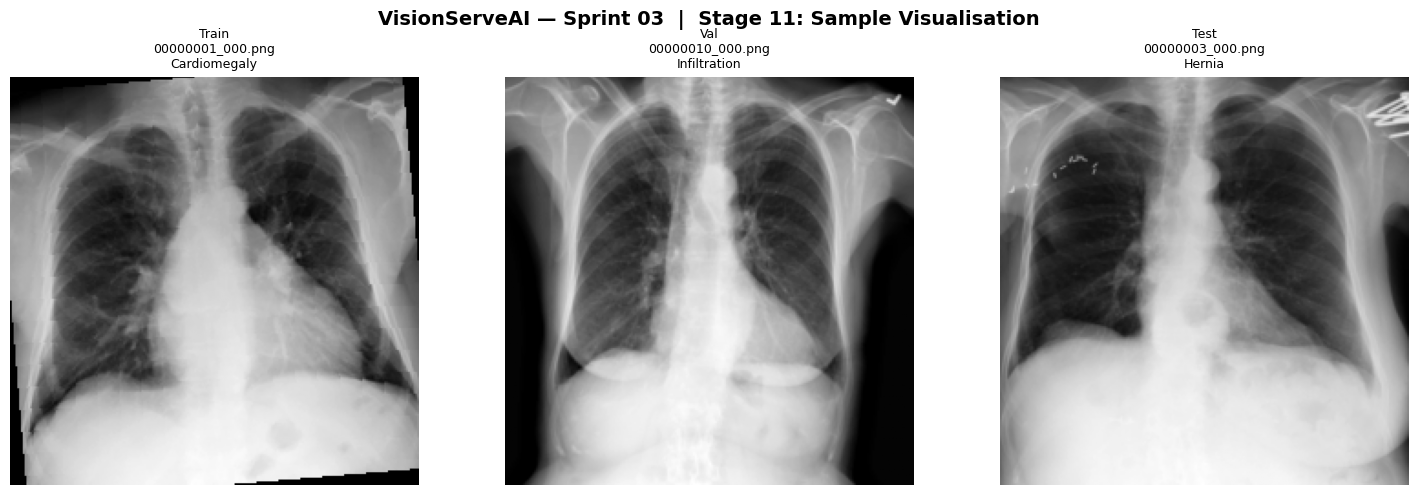

Visualisation complete.


In [29]:
import matplotlib.pyplot as plt

def _denormalize(tensor: torch.Tensor) -> np.ndarray:
    """
    Reverse ImageNet normalisation for visualisation.

    Parameters
    ----------
    tensor : torch.Tensor
        Shape (3, H, W), float32, ImageNet-normalised.

    Returns
    -------
    np.ndarray
        Shape (H, W, 3), uint8, values in [0, 255].
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = tensor * std + mean           # reverse normalisation
    img  = img.clamp(0.0, 1.0)          # clip to valid range
    return (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


# Visualise one sample per split (train, val, test)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "VisionServeAI — Sprint 03  |  Stage 11: Sample Visualisation",
    fontsize=14,
    fontweight="bold",
)

for ax, (split_name, ds) in zip(axes, [
    ("Train", train_dataset),
    ("Val",   val_dataset),
    ("Test",  test_dataset),
]):
    sample = ds[0]
    img_np = _denormalize(sample["image"])
    labels = sample["meta"]["parsed_labels"] or ["No Finding"]

    ax.imshow(img_np[:, :, 0], cmap="gray")  # show R channel (all channels equal for greyscale-converted images)
    ax.set_title(
        f"{split_name}\n{sample['meta']['image_index']}\n{', '.join(labels)}",
        fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()
print("Visualisation complete.")

In [30]:
print("=" * 70)
print("  VisionServeAI | Sprint 03 | Milestone 2 — Stages 8–11")
print("=" * 70)
print()
print("  Stage  8  — Patient Split (NIH-official + stratified 80/20) : PASSED")
print("  Stage  9  — Transform Pipelines                              : PASSED")
print("  Stage 10  — ChestXrayDataset                                 : PASSED")
print("  Stage 11  — Dataset Verification                             : PASSED")
print()
print("  Persisted artefacts:")
print(f"    {cfg.OUTPUT_DIR / 'train_manifest_v1.csv'}")
print(f"    {cfg.OUTPUT_DIR / 'val_manifest_v1.csv'}")
print(f"    {cfg.OUTPUT_DIR / 'test_manifest_v1.csv'}")
print(f"    {cfg.OUTPUT_DIR / 'disease_registry_v1.json'}")
print()
print("  Dataset sizes:")
print(f"    train_dataset : {len(train_dataset):>7,} samples")
print(f"    val_dataset   : {len(val_dataset):>7,} samples")
print(f"    test_dataset  : {len(test_dataset):>7,} samples")
print(f"    total         : {len(train_dataset)+len(val_dataset)+len(test_dataset):>7,} samples")
print()
print("  Ready for Sprint 04:")
print("    → training/dataset.py    (ChestXrayDataset — copy Stage 10 cell)")
print("    → training/transforms.py (build_*_transform — copy Stage 9 cell)")
print("    → training/split.py      (build_patient_split — copy Stage 8 cell)")
print()
print("=" * 70)
print("  STOP — Milestone 2 complete.  Do NOT implement beyond Stage 11.")
print("=" * 70)


  VisionServeAI | Sprint 03 | Milestone 2 — Stages 8–11

  Stage  8  — Patient Split (NIH-official + stratified 80/20) : PASSED
  Stage  9  — Transform Pipelines                              : PASSED
  Stage 10  — ChestXrayDataset                                 : PASSED
  Stage 11  — Dataset Verification                             : PASSED

  Persisted artefacts:
    /kaggle/working/visionserveai/sprint03/train_manifest_v1.csv
    /kaggle/working/visionserveai/sprint03/val_manifest_v1.csv
    /kaggle/working/visionserveai/sprint03/test_manifest_v1.csv
    /kaggle/working/visionserveai/sprint03/disease_registry_v1.json

  Dataset sizes:
    train_dataset :  69,587 samples
    val_dataset   :  16,937 samples
    test_dataset  :  25,596 samples
    total         : 112,120 samples

  Ready for Sprint 04:
    → training/dataset.py    (ChestXrayDataset — copy Stage 10 cell)
    → training/transforms.py (build_*_transform — copy Stage 9 cell)
    → training/split.py      (build_patient_spli

In [31]:
from pathlib import Path

artifact_root = cfg.OUTPUT_DIR

MANIFEST_DIR = artifact_root / "manifests"
REGISTRY_DIR = artifact_root / "registry"
STATISTICS_DIR = artifact_root / "statistics"
CONFIG_DIR = artifact_root / "config"

for directory in [
    MANIFEST_DIR,
    REGISTRY_DIR,
    STATISTICS_DIR,
    CONFIG_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Artifact directories created successfully.")

for d in [
    MANIFEST_DIR,
    REGISTRY_DIR,
    STATISTICS_DIR,
    CONFIG_DIR,
]:
    print(d)

Artifact directories created successfully.
/kaggle/working/visionserveai/sprint03/manifests
/kaggle/working/visionserveai/sprint03/registry
/kaggle/working/visionserveai/sprint03/statistics
/kaggle/working/visionserveai/sprint03/config


In [32]:
print("=" * 70)
print("Saving Manifests")
print("=" * 70)

# --------------------------------------------------------
# CSV
# --------------------------------------------------------

train_manifest.to_csv(
    MANIFEST_DIR / "train_manifest.csv",
    index=False,
)

val_manifest.to_csv(
    MANIFEST_DIR / "val_manifest.csv",
    index=False,
)

test_manifest.to_csv(
    MANIFEST_DIR / "test_manifest.csv",
    index=False,
)

print("CSV manifests saved.")

# --------------------------------------------------------
# Prepare copies for Parquet
# --------------------------------------------------------

def prepare_manifest_for_parquet(df):

    df = df.copy()

    if "image_path" in df.columns:
        df["image_path"] = df["image_path"].astype(str)

    if "parsed_labels" in df.columns:
        df["parsed_labels"] = df["parsed_labels"].apply(list)

    if "encoded_labels" in df.columns:
        df["encoded_labels"] = df["encoded_labels"].apply(
            lambda x: x.tolist() if hasattr(x, "tolist") else list(x)
        )

    return df


train_parquet = prepare_manifest_for_parquet(train_manifest)

val_parquet = prepare_manifest_for_parquet(val_manifest)

test_parquet = prepare_manifest_for_parquet(test_manifest)

# --------------------------------------------------------
# Save Parquet
# --------------------------------------------------------

train_parquet.to_parquet(
    MANIFEST_DIR / "train_manifest.parquet",
    index=False,
)

val_parquet.to_parquet(
    MANIFEST_DIR / "val_manifest.parquet",
    index=False,
)

test_parquet.to_parquet(
    MANIFEST_DIR / "test_manifest.parquet",
    index=False,
)

print("Parquet manifests saved.")

print()
print("Manifest persistence completed successfully.")

Saving Manifests
CSV manifests saved.
Parquet manifests saved.

Manifest persistence completed successfully.


In [33]:
import json

registry = {
    "diseases": CANONICAL_DISEASES,
    "disease_to_index": DISEASE_TO_INDEX,
    "index_to_disease": INDEX_TO_DISEASE,
}

with open(
    REGISTRY_DIR / "disease_registry.json",
    "w",
) as f:
    json.dump(
        registry,
        f,
        indent=4,
    )

print("Disease registry saved.")

Disease registry saved.


In [34]:
statistics = {

    "total_images": len(manifest),

    "train_images": len(train_manifest),

    "validation_images": len(val_manifest),

    "test_images": len(test_manifest),

    "patients": manifest.patient_id.nunique(),

    "num_classes": cfg.NUM_CLASSES,

    "image_size": list(cfg.IMAGE_SIZE),

}

In [35]:
with open(
    STATISTICS_DIR / "dataset_statistics.json",
    "w",
) as f:

    json.dump(
        statistics,
        f,
        indent=4,
    )

print("Statistics saved.")

Statistics saved.


In [36]:
from dataclasses import asdict

config = {}

for field in cfg.__dataclass_fields__:

    value = getattr(cfg, field)

    if isinstance(value, Path):
        value = str(value)

    config[field] = value

with open(
    CONFIG_DIR / "pipeline_config.json",
    "w",
) as f:

    json.dump(
        config,
        f,
        indent=4,
    )

print("Pipeline configuration saved.")

Pipeline configuration saved.


In [37]:
print("=" * 70)
print("Persisted Artifacts")
print("=" * 70)

for path in sorted(artifact_root.rglob("*")):

    print(path.relative_to(artifact_root))

Persisted Artifacts
config
config/pipeline_config.json
disease_registry_v1.json
manifests
manifests/test_manifest.csv
manifests/test_manifest.parquet
manifests/train_manifest.csv
manifests/train_manifest.parquet
manifests/val_manifest.csv
manifests/val_manifest.parquet
registry
registry/disease_registry.json
statistics
statistics/dataset_statistics.json
test_manifest_v1.csv
train_manifest_v1.csv
val_manifest_v1.csv


# ─────────────────────────────────────────────────────────────────────────────
# STAGE 12 — IMPLEMENTATION
# ─────────────────────────────────────────────────────────────────────────────
# ============================================================
# VisionServeAI | Sprint 03
# Stage 12: Production DataLoader Engineering
#
# Module: training/dataloader.py → build_dataloaders()
# ============================================================

In [46]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data.dataloader import default_collate


def _supports_persistent_workers(num_workers: int) -> bool:
    """
    Return True when persistent_workers can safely be enabled.

    persistent_workers=True requires num_workers > 0.  Enabling it with
    num_workers=0 raises a ValueError at DataLoader construction time.
    """
    return num_workers > 0


def _supports_prefetch_factor(num_workers: int) -> bool:
    """
    Return True when prefetch_factor can safely be passed.

    prefetch_factor is only meaningful (and accepted without a warning) when
    num_workers > 0.  Passing it with num_workers=0 triggers a
    UserWarning in recent PyTorch versions.
    """
    return num_workers > 0


def _build_worker_init_fn(seed: int):
    """
    Return a worker initialisation function that re-seeds each DataLoader
    worker deterministically.

    PyTorch spawns num_workers independent sub-processes; without explicit
    seeding, each worker inherits the same RNG state and produces correlated
    random augmentation sequences.  The canonical fix is to seed each worker
    with ``base_seed + worker_id`` so they diverge deterministically.

    Parameters
    ----------
    seed : int
        Base seed (typically cfg.RANDOM_SEED).

    Returns
    -------
    Callable[[int], None]
        A function ``worker_init_fn(worker_id: int) -> None`` suitable for
        passing directly to ``DataLoader(worker_init_fn=...)``.
    """
    def worker_init_fn(worker_id: int) -> None:
        import random
        import numpy as np
        worker_seed = seed + worker_id
        random.seed(worker_seed)
        np.random.seed(worker_seed)
        torch.manual_seed(worker_seed)

    return worker_init_fn


def chest_xray_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Custom collate function for ChestXrayDataset batches.

    The dataset's ``meta`` dict contains ``parsed_labels``, a variable-length
    list of disease-name strings.  PyTorch's ``default_collate`` requires all
    elements in a batched list to have the same size, so it raises
    ``RuntimeError: each element in list of batch should be of equal size``
    when it encounters this field.

    Resolution
    ----------
    * ``parsed_labels`` — kept as a plain Python list-of-lists.  The training
      engine iterates over it for logging/analysis, never passes it through
      a tensor op, so no padding or encoding is needed.
    * All other fields — delegated to ``default_collate``, preserving the
      normal tensor-stacking behaviour for ``image``, ``labels``, and the
      remaining scalar metadata fields.

    This function is the single entry point for all three DataLoaders
    (train / val / test); it is passed as ``collate_fn=chest_xray_collate_fn``
    at construction time.

    Parameters
    ----------
    batch : List[Dict[str, Any]]
        Raw per-sample dicts returned by ``ChestXrayDataset.__getitem__``.

    Returns
    -------
    Dict[str, Any]
        Collated batch with keys ``image``, ``labels``, and ``meta``.
    """
    # Separate the variable-length field before calling default_collate.
    parsed_labels_batch: List[List[str]] = [
        sample["meta"]["parsed_labels"] for sample in batch
    ]

    # Build a collatable batch with parsed_labels temporarily removed.
    collatable = []
    for sample in batch:
        meta_copy = {k: v for k, v in sample["meta"].items()
                     if k != "parsed_labels"}
        collatable.append({
            "image":  sample["image"],
            "labels": sample["labels"],
            "meta":   meta_copy,
        })

    collated = default_collate(collatable)

    # Re-attach parsed_labels as a plain list-of-lists.
    collated["meta"]["parsed_labels"] = parsed_labels_batch

    return collated

def build_train_loader(
    dataset: "ChestXrayDataset",
    batch_size: int,
    num_workers: int,
    seed: int,
    pin_memory: bool = True,
    drop_last: bool = True,
    prefetch_factor: int = 2,
) -> DataLoader:
    """
    Build the production training DataLoader.

    Design decisions
    ----------------
    * shuffle=True : batches must be independently and identically distributed
      across epochs.  Using a seeded torch.Generator ensures that the shuffle
      order is reproducible across runs.
    * drop_last=True : the final incomplete batch is dropped so every gradient
      step sees exactly ``batch_size`` samples.  This prevents BatchNorm
      instability with a single-sample remainder batch and keeps throughput
      estimates precise.
    * pin_memory=True : pre-pins CPU tensors for faster host→GPU transfer via
      DMA; has no effect when no GPU is present (harmless).
    * persistent_workers : kept alive between epochs to amortise fork overhead;
      only enabled when num_workers > 0.
    * prefetch_factor : each worker pre-fetches this many batches ahead of the
      training loop, hiding I/O latency; only passed when num_workers > 0.
    * worker_init_fn : independently seeds each worker's Python / NumPy / Torch
      RNG so augmentation randomness is deterministic and uncorrelated across
      workers.

    Parameters
    ----------
    dataset : ChestXrayDataset
        The training split dataset (Stage 10).
    batch_size : int
        Number of samples per batch (from PipelineConfig.BATCH_SIZE).
    num_workers : int
        Number of parallel data-loading workers (from PipelineConfig.NUM_WORKERS).
    seed : int
        Base random seed for the Generator and worker_init_fn.
    pin_memory : bool
        Pre-pin CPU tensors for faster GPU transfer.  Default True.
    drop_last : bool
        Drop the final incomplete batch.  Default True.
    prefetch_factor : int
        Batches pre-fetched per worker ahead of the training loop.  Default 2.

    Returns
    -------
    torch.utils.data.DataLoader
        Ready-to-iterate training DataLoader.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)

    kwargs: dict = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=drop_last,
        generator=generator,
        worker_init_fn=_build_worker_init_fn(seed),
        collate_fn=chest_xray_collate_fn,
    )

    if _supports_persistent_workers(num_workers):
        kwargs["persistent_workers"] = True

    if _supports_prefetch_factor(num_workers):
        kwargs["prefetch_factor"] = prefetch_factor

    loader = DataLoader(**kwargs)
    logger.info(
        "train_loader built.  samples=%d  batch_size=%d  "
        "num_workers=%d  drop_last=%s  pin_memory=%s.",
        len(dataset), batch_size, num_workers, drop_last, pin_memory,
    )
    return loader


def build_val_loader(
    dataset: "ChestXrayDataset",
    batch_size: int,
    num_workers: int,
    seed: int,
    pin_memory: bool = True,
    prefetch_factor: int = 2,
) -> DataLoader:
    """
    Build the production validation DataLoader.

    Design decisions
    ----------------
    * shuffle=False : validation metrics must be computed on a fixed,
      deterministic sample order so results are directly comparable across
      epochs and between runs.
    * drop_last=False : every validation sample is evaluated; dropping any
      sample would bias the reported metric.
    * pin_memory and num_workers follow the same rationale as the training
      loader.

    Parameters
    ----------
    dataset : ChestXrayDataset
        The validation split dataset (Stage 10).
    batch_size : int
        Number of samples per batch.
    num_workers : int
        Number of parallel data-loading workers.
    seed : int
        Base seed for worker_init_fn (ensures deterministic worker RNGs).
    pin_memory : bool
        Pre-pin CPU tensors.  Default True.
    prefetch_factor : int
        Batches pre-fetched per worker.  Default 2.

    Returns
    -------
    torch.utils.data.DataLoader
        Ready-to-iterate validation DataLoader.
    """
    kwargs: dict = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        worker_init_fn=_build_worker_init_fn(seed),
        collate_fn=chest_xray_collate_fn,
    )

    if _supports_persistent_workers(num_workers):
        kwargs["persistent_workers"] = True

    if _supports_prefetch_factor(num_workers):
        kwargs["prefetch_factor"] = prefetch_factor

    loader = DataLoader(**kwargs)
    logger.info(
        "val_loader built.  samples=%d  batch_size=%d  "
        "num_workers=%d  pin_memory=%s.",
        len(dataset), batch_size, num_workers, pin_memory,
    )
    return loader


def build_test_loader(
    dataset: "ChestXrayDataset",
    batch_size: int,
    num_workers: int,
    seed: int,
    pin_memory: bool = True,
    prefetch_factor: int = 2,
) -> DataLoader:
    """
    Build the production test DataLoader.

    Design decisions
    ----------------
    * shuffle=False : test-set evaluation must be fully deterministic.
    * drop_last=False : every test sample must be scored.
    * Identical to val_loader in structure; named separately so production
      inference code imports a clearly-named artefact without coupling to
      the validation-split concept.

    Parameters
    ----------
    dataset : ChestXrayDataset
        The test split dataset (Stage 10).
    batch_size : int
        Number of samples per batch.
    num_workers : int
        Number of parallel data-loading workers.
    seed : int
        Base seed for worker_init_fn.
    pin_memory : bool
        Pre-pin CPU tensors.  Default True.
    prefetch_factor : int
        Batches pre-fetched per worker.  Default 2.

    Returns
    -------
    torch.utils.data.DataLoader
        Ready-to-iterate test DataLoader.
    """
    kwargs: dict = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        worker_init_fn=_build_worker_init_fn(seed),
        collate_fn=chest_xray_collate_fn,
    )

    if _supports_persistent_workers(num_workers):
        kwargs["persistent_workers"] = True

    if _supports_prefetch_factor(num_workers):
        kwargs["prefetch_factor"] = prefetch_factor

    loader = DataLoader(**kwargs)
    logger.info(
        "test_loader built.  samples=%d  batch_size=%d  "
        "num_workers=%d  pin_memory=%s.",
        len(dataset), batch_size, num_workers, pin_memory,
    )
    return loader


def build_dataloaders(
    train_dataset: "ChestXrayDataset",
    val_dataset: "ChestXrayDataset",
    test_dataset: "ChestXrayDataset",
    batch_size: int,
    num_workers: int,
    seed: int,
    pin_memory: bool = True,
    drop_last_train: bool = True,
    prefetch_factor: int = 2,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Convenience factory that constructs all three production DataLoaders.

    This is the single entry point consumed by the training engine in Sprint 04.
    It delegates each loader to its dedicated builder function, keeping each
    builder testable in isolation.

    Parameters
    ----------
    train_dataset : ChestXrayDataset
    val_dataset   : ChestXrayDataset
    test_dataset  : ChestXrayDataset
    batch_size    : int
    num_workers   : int
    seed          : int
    pin_memory    : bool
    drop_last_train : bool
        Drop the final incomplete training batch.  Default True.
    prefetch_factor : int

    Returns
    -------
    Tuple[DataLoader, DataLoader, DataLoader]
        (train_loader, val_loader, test_loader)
    """
    train_loader = build_train_loader(
        dataset=train_dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
        pin_memory=pin_memory,
        drop_last=drop_last_train,
        prefetch_factor=prefetch_factor,
    )
    val_loader = build_val_loader(
        dataset=val_dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
        pin_memory=pin_memory,
        prefetch_factor=prefetch_factor,
    )
    test_loader = build_test_loader(
        dataset=test_dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
        pin_memory=pin_memory,
        prefetch_factor=prefetch_factor,
    )
    logger.info("All three DataLoaders constructed successfully.")
    return train_loader, val_loader, test_loader


In [47]:
print("=" * 70)
print("STAGE 12 — PRODUCTION DATALOADER ENGINEERING")
print("=" * 70)
print()

train_loader, val_loader, test_loader = build_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=cfg.BATCH_SIZE,
    num_workers=cfg.NUM_WORKERS,
    seed=cfg.RANDOM_SEED,
    pin_memory=True,
    drop_last_train=True,
    prefetch_factor=2,
)

print(f"  train_loader  : batch_size={train_loader.batch_size}  "
      f"shuffle=True  drop_last=True  "
      f"num_workers={train_loader.num_workers}")
print(f"  val_loader    : batch_size={val_loader.batch_size}  "
      f"shuffle=False  drop_last=False  "
      f"num_workers={val_loader.num_workers}")
print(f"  test_loader   : batch_size={test_loader.batch_size}  "
      f"shuffle=False  drop_last=False  "
      f"num_workers={test_loader.num_workers}")
print()
print("Stage 12 — Production DataLoader Engineering : PASSED")



STAGE 12 — PRODUCTION DATALOADER ENGINEERING

2026-06-30 00:07:12 | INFO     | visionserveai.sprint03 | train_loader built.  samples=69587  batch_size=32  num_workers=2  drop_last=True  pin_memory=True.
2026-06-30 00:07:12 | INFO     | visionserveai.sprint03 | val_loader built.  samples=16937  batch_size=32  num_workers=2  pin_memory=True.
2026-06-30 00:07:12 | INFO     | visionserveai.sprint03 | test_loader built.  samples=25596  batch_size=32  num_workers=2  pin_memory=True.
2026-06-30 00:07:12 | INFO     | visionserveai.sprint03 | All three DataLoaders constructed successfully.
  train_loader  : batch_size=32  shuffle=True  drop_last=True  num_workers=2
  val_loader    : batch_size=32  shuffle=False  drop_last=False  num_workers=2
  test_loader   : batch_size=32  shuffle=False  drop_last=False  num_workers=2

Stage 12 — Production DataLoader Engineering : PASSED


# ─────────────────────────────────────────────────────────────────────────────
# STAGE 13 — IMPLEMENTATION + VALIDATION
# ─────────────────────────────────────────────────────────────────────────────
# ============================================================
# VisionServeAI | Sprint 03
# Stage 13: Batch Verification
#
# Module: training/dataloader.py → verify_loader()
# ============================================================

In [48]:
import time
import math

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def _batch_memory_mb(image_batch: torch.Tensor, label_batch: torch.Tensor) -> float:
    """
    Estimate combined memory footprint (MB) of one batch's tensors.

    Parameters
    ----------
    image_batch : torch.Tensor   Shape (B, C, H, W), float32.
    label_batch : torch.Tensor   Shape (B, 14), float32.

    Returns
    -------
    float
        Approximate memory in mebibytes (MiB).
    """
    image_bytes = image_batch.element_size() * image_batch.nelement()
    label_bytes = label_batch.element_size() * label_batch.nelement()
    return (image_bytes + label_bytes) / (1024 ** 2)


def _check_metadata_integrity(meta: dict, batch_size: int) -> None:
    """..."""
    required_keys = {"image_index", "patient_id", "finding_labels",
                     "parsed_labels", "num_labels"}
    assert required_keys.issubset(meta.keys()), (
        f"Metadata missing keys: {required_keys - set(meta.keys())}."
    )
    assert len(meta["image_index"]) == batch_size, (
        f"image_index length {len(meta['image_index'])} != batch_size {batch_size}."
    )
    assert len(meta["patient_id"]) == batch_size, (
        f"patient_id length {len(meta['patient_id'])} != batch_size {batch_size}."
    )
    # parsed_labels: list-of-lists (variable length per sample — not collated into tensor)
    assert isinstance(meta["parsed_labels"], list), (
        f"parsed_labels should be list, got {type(meta['parsed_labels']).__name__}."
    )
    assert len(meta["parsed_labels"]) == batch_size, (
        f"parsed_labels length {len(meta['parsed_labels'])} != batch_size {batch_size}."
    )
    for nl in meta["num_labels"]:
        assert int(nl) >= 0, f"num_labels contains negative value: {nl}."


def verify_loader(
    loader: DataLoader,
    split_name: str,
    expected_dataset_len: int,
    num_classes: int,
    batch_size: int,
    drop_last: bool,
) -> dict:
    """
    Exhaustively verify a DataLoader meets production requirements.

    Checks
    ------
    1.  Dataset length matches the split manifest.
    2.  Number of batches is mathematically correct given drop_last.
    3.  First batch retrieval does not error.
    4.  Image batch shape is (B, 3, 224, 224).
    5.  Label batch shape is (B, 14).
    6.  Metadata dict is complete and internally consistent.
    7.  Image tensor dtype is torch.float32.
    8.  Label tensor dtype is torch.float32.
    9.  Tensors live on CPU (expected pre-training; moved by trainer in Sprint 04).
    10. Batch memory footprint is logged in MiB.
    11. GPU compatibility flag is reported.
    12. Throughput estimation (samples/sec) based on first-batch wall time.

    Parameters
    ----------
    loader            : DataLoader to verify.
    split_name        : Human-readable label ("Train", "Val", "Test").
    expected_dataset_len : Exact sample count the split manifest holds.
    num_classes       : Expected label vector length (14).
    batch_size        : Configured batch size.
    drop_last         : Whether the loader drops the last incomplete batch.

    Returns
    -------
    dict
        Summary dict with all measured values (used by the print summary).
    """
    width = 70
    print("-" * width)
    print(f"  {split_name} Loader")
    print("-" * width)

    # ── 1. Dataset length ────────────────────────────────────
    actual_len = len(loader.dataset)
    assert actual_len == expected_dataset_len, (
        f"[{split_name}] Dataset length {actual_len:,} != "
        f"expected {expected_dataset_len:,}."
    )
    print(f"  ✔  Dataset length        : {actual_len:,}")

    # ── 2. Expected batch count ───────────────────────────────
    if drop_last:
        expected_batches = math.floor(actual_len / batch_size)
    else:
        expected_batches = math.ceil(actual_len / batch_size)
    actual_batches = len(loader)
    assert actual_batches == expected_batches, (
        f"[{split_name}] Batch count {actual_batches} != "
        f"expected {expected_batches} (drop_last={drop_last})."
    )
    print(f"  ✔  Number of batches     : {actual_batches:,}  "
          f"(drop_last={drop_last})")

    # ── 3–12. First batch inspection ─────────────────────────
    t0 = time.perf_counter()
    batch = next(iter(loader))
    elapsed = time.perf_counter() - t0

    images = batch["image"]
    labels = batch["labels"]
    meta   = batch["meta"]

    actual_bs = images.shape[0]

    # ── 4. Image batch shape ──────────────────────────────────
    expected_image_shape = (actual_bs, 3, 224, 224)
    assert tuple(images.shape) == expected_image_shape, (
        f"[{split_name}] Image shape {tuple(images.shape)} != "
        f"{expected_image_shape}."
    )
    print(f"  ✔  Image batch shape     : {tuple(images.shape)}")

    # ── 5. Label batch shape ──────────────────────────────────
    expected_label_shape = (actual_bs, num_classes)
    assert tuple(labels.shape) == expected_label_shape, (
        f"[{split_name}] Label shape {tuple(labels.shape)} != "
        f"{expected_label_shape}."
    )
    print(f"  ✔  Label batch shape     : {tuple(labels.shape)}")

    # ── 6. Metadata integrity ─────────────────────────────────
    _check_metadata_integrity(meta, actual_bs)
    print(f"  ✔  Metadata integrity    : OK  (keys={sorted(meta.keys())})")

    # ── 7. Image dtype ────────────────────────────────────────
    assert images.dtype == torch.float32, (
        f"[{split_name}] Image dtype {images.dtype} != torch.float32."
    )
    print(f"  ✔  Image tensor dtype    : {images.dtype}")

    # ── 8. Label dtype ────────────────────────────────────────
    assert labels.dtype == torch.float32, (
        f"[{split_name}] Label dtype {labels.dtype} != torch.float32."
    )
    print(f"  ✔  Label tensor dtype    : {labels.dtype}")

    # ── 9. Tensor device ──────────────────────────────────────
    assert images.device.type == "cpu", (
        f"[{split_name}] Unexpected device: {images.device}.  "
        "Tensors must be on CPU before being moved by the trainer."
    )
    print(f"  ✔  Tensor device         : {images.device}")

    # ── 10. Batch memory footprint ────────────────────────────
    mem_mb = _batch_memory_mb(images, labels)
    print(f"  ✔  Batch memory footprint: {mem_mb:.2f} MiB  "
          f"({actual_bs} samples × (3×224×224 + 14) float32)")

    # ── 11. GPU compatibility ─────────────────────────────────
    cuda_available = torch.cuda.is_available()
    print(f"  ✔  GPU compatibility     : CUDA available = {cuda_available}")

    # ── 12. Throughput estimation ─────────────────────────────
    throughput = actual_bs / elapsed if elapsed > 0 else float("inf")
    print(f"  ✔  First-batch wall time : {elapsed:.3f}s  "
          f"(~{throughput:,.0f} samples/s)")

    return {
        "split":         split_name,
        "dataset_len":   actual_len,
        "num_batches":   actual_batches,
        "image_shape":   tuple(images.shape),
        "label_shape":   tuple(labels.shape),
        "image_dtype":   str(images.dtype),
        "label_dtype":   str(labels.dtype),
        "device":        str(images.device),
        "mem_mb":        mem_mb,
        "cuda_available": cuda_available,
        "throughput_sps": throughput,
        "first_batch":   batch,   # kept for visualisation cell below
    }

In [49]:
print("=" * 70)
print("STAGE 13 — BATCH VERIFICATION")
print("=" * 70)
print()

train_summary = verify_loader(
    loader=train_loader,
    split_name="Train",
    expected_dataset_len=len(train_dataset),
    num_classes=cfg.NUM_CLASSES,
    batch_size=cfg.BATCH_SIZE,
    drop_last=True,
)
print()

val_summary = verify_loader(
    loader=val_loader,
    split_name="Val",
    expected_dataset_len=len(val_dataset),
    num_classes=cfg.NUM_CLASSES,
    batch_size=cfg.BATCH_SIZE,
    drop_last=False,
)
print()

test_summary = verify_loader(
    loader=test_loader,
    split_name="Test",
    expected_dataset_len=len(test_dataset),
    num_classes=cfg.NUM_CLASSES,
    batch_size=cfg.BATCH_SIZE,
    drop_last=False,
)
print()

# ── Engineering Summary ───────────────────────────────────────
print("=" * 70)
print("  STAGE 13 — ENGINEERING SUMMARY")
print("=" * 70)
print()
print(f"  {'Split':<10} {'Samples':>9} {'Batches':>9} "
      f"{'Mem/Batch':>12} {'Throughput':>14}")
print(f"  {'-'*10} {'-'*9} {'-'*9} {'-'*12} {'-'*14}")
for s in [train_summary, val_summary, test_summary]:
    print(
        f"  {s['split']:<10} {s['dataset_len']:>9,} {s['num_batches']:>9,} "
        f"{s['mem_mb']:>10.2f} MiB {s['throughput_sps']:>12,.0f} sps"
    )
print()
print(f"  Batch size       : {cfg.BATCH_SIZE}")
print(f"  Num workers      : {cfg.NUM_WORKERS}")
print(f"  CUDA available   : {train_summary['cuda_available']}")
print()
print("Stage 13 — Batch Verification : PASSED")



STAGE 13 — BATCH VERIFICATION

----------------------------------------------------------------------
  Train Loader
----------------------------------------------------------------------
  ✔  Dataset length        : 69,587
  ✔  Number of batches     : 2,174  (drop_last=True)
  ✔  Image batch shape     : (32, 3, 224, 224)
  ✔  Label batch shape     : (32, 14)
  ✔  Metadata integrity    : OK  (keys=['finding_labels', 'image_index', 'num_labels', 'parsed_labels', 'patient_id'])
  ✔  Image tensor dtype    : torch.float32
  ✔  Label tensor dtype    : torch.float32
  ✔  Tensor device         : cpu
  ✔  Batch memory footprint: 18.38 MiB  (32 samples × (3×224×224 + 14) float32)
  ✔  GPU compatibility     : CUDA available = False
  ✔  First-batch wall time : 1.140s  (~28 samples/s)

----------------------------------------------------------------------
  Val Loader
----------------------------------------------------------------------
  ✔  Dataset length        : 16,937
  ✔  Number of batches 

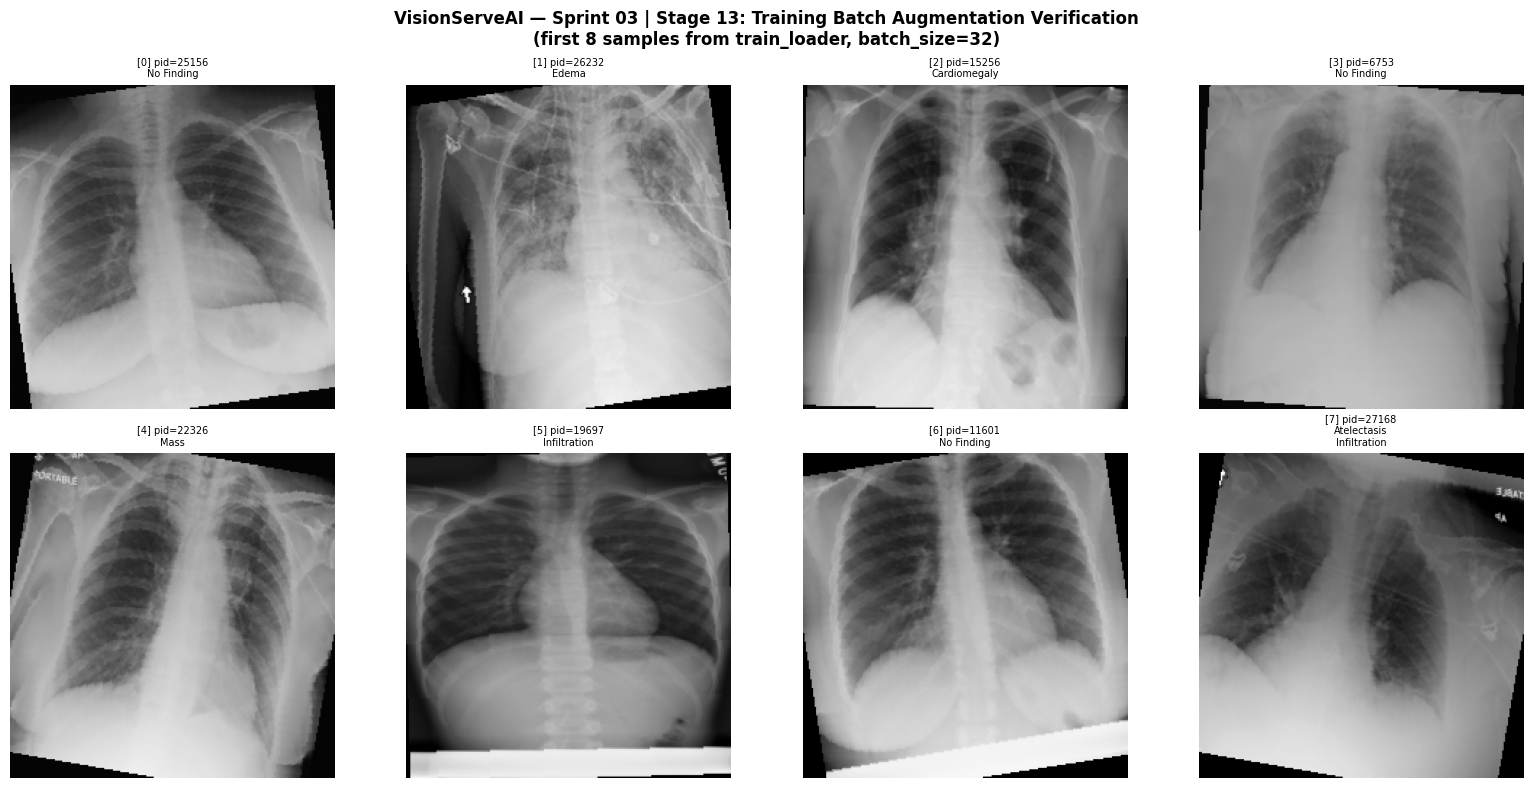

Training batch augmentation visualisation complete (8 samples shown).


In [56]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

_VIZ_COLS: int = 4   # samples per row
_VIZ_ROWS: int = 2   # rows in the grid


def _denormalize_batch(tensor: torch.Tensor) -> np.ndarray:
    """
    Reverse ImageNet normalisation on a batch tensor for visualisation.

    Parameters
    ----------
    tensor : torch.Tensor
        Shape (B, 3, H, W), float32, ImageNet-normalised.

    Returns
    -------
    np.ndarray
        Shape (B, H, W, 3), uint8, clipped to [0, 255].
    """
    mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
    imgs = tensor * std + mean
    imgs = imgs.clamp(0.0, 1.0)
    return (imgs.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)


first_batch   = train_summary["first_batch"]
images_batch  = first_batch["image"]           # (B, 3, 224, 224)
labels_batch  = first_batch["labels"]          # (B, 14)
meta_batch    = first_batch["meta"]

n_vis  = _VIZ_ROWS * _VIZ_COLS
imgs_np = _denormalize_batch(images_batch[:n_vis])

fig, axes = plt.subplots(
    _VIZ_ROWS, _VIZ_COLS,
    figsize=(4 * _VIZ_COLS, 4 * _VIZ_ROWS),
)
fig.suptitle(
    "VisionServeAI — Sprint 03 | Stage 13: Training Batch Augmentation Verification\n"
    f"(first {n_vis} samples from train_loader, batch_size={cfg.BATCH_SIZE})",
    fontsize=12,
    fontweight="bold",
)

for i, ax in enumerate(axes.flat):
    img_np     = imgs_np[i]
    # X-ray images are stored as single-channel; all three RGB channels are
    # equal after convert("RGB").  Display the R channel as greyscale.
    ax.imshow(img_np[:, :, 0], cmap="gray", vmin=0, vmax=255)

    disease_names = decode_labels(labels_batch[i].numpy())
    title_text    = "\n".join(disease_names) if disease_names else "No Finding"
    short_index   = meta_batch["image_index"][i].split("_")[0]

    ax.set_title(
        f"[{i}] pid={int(meta_batch['patient_id'][i])}\n{title_text}",
        fontsize=7,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Training batch augmentation visualisation complete ({n_vis} samples shown).")


# ─────────────────────────────────────────────────────────────────────────────
# STAGE 14 — IMPLEMENTATION
# ─────────────────────────────────────────────────────────────────────────────
# VisionServeAI | Sprint 03
# Stage 14: Advanced Dataset Statistics
#
# Generates three production artifacts consumed by Sprint 04:
#   - statistics/class_distribution.json
#   - statistics/class_weights.json
#   - statistics/dataset_summary.json
#
# Module: training/metadata.py → compute_class_statistics()
# ============================================================


In [57]:
import json


def _stack_encoded_labels(manifest_df: pd.DataFrame) -> np.ndarray:
    """
    Stack the encoded_labels column of a manifest DataFrame into a
    2-D NumPy array.

    Parameters
    ----------
    manifest_df : pd.DataFrame
        A split manifest with an ``encoded_labels`` column whose values
        are numpy float32 arrays of shape (14,).

    Returns
    -------
    np.ndarray
        Shape (N, 14), dtype float32.
    """
    return np.stack(manifest_df["encoded_labels"].values).astype(np.float32)


def compute_class_distribution(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    disease_names: Tuple[str, ...],
) -> dict:
    """
    Compute per-class positive and negative sample counts across all splits.

    For each disease class and each split (train / val / test / all), the
    following quantities are computed:

    * ``positive_samples`` — number of rows where the class label is 1.
    * ``negative_samples`` — number of rows where the class label is 0.
    * ``positive_frequency`` — positive_samples / total_samples for that split.
    * ``imbalance_ratio``   — negative_samples / positive_samples; quantifies
      how many negative examples exist for each positive.  A value of 20 means
      the class is present in 1 of every 21 images.

    These figures are produced per-split (not only for the full dataset) so the
    training engine can verify that the patient-stratified split has preserved
    the class-frequency profile without significant drift.

    Parameters
    ----------
    train_df : pd.DataFrame
    val_df   : pd.DataFrame
    test_df  : pd.DataFrame
    disease_names : Tuple[str, ...]
        Ordered disease names from the frozen registry (CANONICAL_DISEASES).

    Returns
    -------
    dict
        Nested structure: {disease_name: {split_name: {metric: value}}}.
    """
    splits = {
        "train": train_df,
        "val":   val_df,
        "test":  test_df,
        "all":   pd.concat([train_df, val_df, test_df], ignore_index=True),
    }

    distribution: dict = {}

    for class_idx, disease in enumerate(disease_names):
        distribution[disease] = {}

        for split_name, df in splits.items():
            labels_2d = _stack_encoded_labels(df)
            col = labels_2d[:, class_idx]

            positive = int(col.sum())
            total    = len(df)
            negative = total - positive

            pos_freq       = positive / total if total > 0 else 0.0
            imbalance_ratio = (negative / positive) if positive > 0 else float("inf")

            distribution[disease][split_name] = {
                "positive_samples":  positive,
                "negative_samples":  negative,
                "total_samples":     total,
                "positive_frequency": round(pos_freq, 6),
                "imbalance_ratio":   round(imbalance_ratio, 4)
                                     if imbalance_ratio != float("inf")
                                     else "inf",
            }

    return distribution


def compute_class_weights(
    train_df: pd.DataFrame,
    disease_names: Tuple[str, ...],
) -> dict:
    """
    Compute recommended BCEWithLogitsLoss pos_weight values from the
    training split.

    Formula (from PyTorch documentation):
        pos_weight[c] = negative_count[c] / positive_count[c]

    Rationale
    ---------
    BCEWithLogitsLoss accepts a ``pos_weight`` vector that rescales the
    loss contribution of positive examples relative to negative ones.
    Setting pos_weight = neg / pos exactly compensates for class imbalance
    under a balanced-accuracy objective: a class with 20× more negatives than
    positives gets its positive-example loss term upweighted by 20, making
    the model pay equal attention to each class regardless of prevalence.

    The Sprint 04 training engine will load ``class_weights.json`` and
    construct this tensor as:
        pos_weight = torch.tensor([w[d] for d in CANONICAL_DISEASES])
    and pass it to ``BCEWithLogitsLoss(pos_weight=pos_weight)``.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training-split manifest.  Weights are always computed from training
        data only — using val/test statistics would constitute data leakage.
    disease_names : Tuple[str, ...]

    Returns
    -------
    dict
        {disease_name: {"pos_weight": float, "positive_count": int,
                        "negative_count": int}}
    """
    labels_2d = _stack_encoded_labels(train_df)
    total      = len(train_df)
    weights: dict = {}

    for class_idx, disease in enumerate(disease_names):
        col       = labels_2d[:, class_idx]
        positive  = int(col.sum())
        negative  = total - positive

        # Guard against a zero-positive class (would cause division by zero).
        # In NIH ChestXray14 this is not expected, but the guard makes the
        # function safe for other datasets or future domain plugins.
        if positive == 0:
            pos_weight = float("inf")
            logger.warning(
                "Class '%s' has zero positive training examples.  "
                "pos_weight set to inf.",
                disease,
            )
        else:
            pos_weight = round(negative / positive, 6)

        weights[disease] = {
            "pos_weight":      pos_weight,
            "positive_count":  positive,
            "negative_count":  negative,
        }

    return weights


def compute_dataset_summary(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    disease_names: Tuple[str, ...],
    class_weights: dict,
    config: "PipelineConfig",
) -> dict:
    """
    Build a comprehensive dataset-level summary artifact for Sprint 04.

    This artifact is the single authoritative source of dataset facts that the
    training engine reads at startup.  It consolidates every figure needed to
    correctly configure training (class count, image count, split sizes, class
    weights) without requiring Sprint 04 to re-derive them from the manifests.

    Parameters
    ----------
    train_df       : Training manifest.
    val_df         : Validation manifest.
    test_df        : Test manifest.
    disease_names  : Ordered disease names from the frozen registry.
    class_weights  : Output of compute_class_weights().
    config         : PipelineConfig singleton.

    Returns
    -------
    dict
        Flat + nested summary dict, JSON-serialisable.
    """
    all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

    total_patients = int(all_df["patient_id"].nunique())
    train_patients = int(train_df["patient_id"].nunique())
    val_patients   = int(val_df["patient_id"].nunique())
    test_patients  = int(test_df["patient_id"].nunique())

    # Ordered pos_weight list (matches disease_names index order)
    pos_weight_vector = [
        class_weights[d]["pos_weight"] for d in disease_names
    ]

    summary = {
        "schema_version":         config.SCHEMA_VERSION,
        "project":                config.PROJECT_NAME,
        "sprint":                 config.SPRINT,
        # ── Image counts ─────────────────────────────────────
        "total_images":           len(all_df),
        "train_images":           len(train_df),
        "val_images":             len(val_df),
        "test_images":            len(test_df),
        # ── Patient counts ────────────────────────────────────
        "total_patients":         total_patients,
        "train_patients":         train_patients,
        "val_patients":           val_patients,
        "test_patients":          test_patients,
        # ── Image configuration ───────────────────────────────
        "image_size":             list(config.IMAGE_SIZE),
        "num_channels":           3,
        # ── Label configuration ───────────────────────────────
        "num_classes":            config.NUM_CLASSES,
        "disease_names":          list(disease_names),
        # ── Training hyperparameter hints (not frozen) ────────
        "recommended_batch_size": config.BATCH_SIZE,
        "random_seed":            config.RANDOM_SEED,
        # ── Class weights (BCEWithLogitsLoss pos_weight) ──────
        "pos_weight_vector":      pos_weight_vector,
        # ── Splits ───────────────────────────────────────────
        "train_ratio_actual":     round(len(train_df) / len(all_df), 6),
        "val_ratio_actual":       round(len(val_df)   / len(all_df), 6),
        "test_ratio_actual":      round(len(test_df)  / len(all_df), 6),
        # ── ImageNet normalisation constants ──────────────────
        "imagenet_mean":          list(IMAGENET_MEAN),
        "imagenet_std":           list(IMAGENET_STD),
    }
    return summary


# ── Compute all statistics ────────────────────────────────────
print("=" * 70)
print("STAGE 14 — ADVANCED DATASET STATISTICS")
print("=" * 70)
print()

print("  Computing class distribution …")
class_distribution = compute_class_distribution(
    train_df=train_manifest,
    val_df=val_manifest,
    test_df=test_manifest,
    disease_names=CANONICAL_DISEASES,
)
print("  ✔  class_distribution computed.")

print("  Computing class weights (BCEWithLogitsLoss pos_weight) …")
class_weights = compute_class_weights(
    train_df=train_manifest,
    disease_names=CANONICAL_DISEASES,
)
print("  ✔  class_weights computed.")

print("  Building dataset summary …")
dataset_summary = compute_dataset_summary(
    train_df=train_manifest,
    val_df=val_manifest,
    test_df=test_manifest,
    disease_names=CANONICAL_DISEASES,
    class_weights=class_weights,
    config=cfg,
)
print("  ✔  dataset_summary computed.")
print()


STAGE 14 — ADVANCED DATASET STATISTICS

  Computing class distribution …
  ✔  class_distribution computed.
  Computing class weights (BCEWithLogitsLoss pos_weight) …
  ✔  class_weights computed.
  Building dataset summary …
  ✔  dataset_summary computed.



# ============================================================
# VisionServeAI | Sprint 03
# Stage 14: Statistics Validation & Persistence
# ============================================================

# ── Validation ────────────────────────────────────────────────



In [58]:
print("Stage 14 — Validation")
print("-" * 70)

# Verify all 14 diseases are present in distribution
assert set(class_distribution.keys()) == set(CANONICAL_DISEASES), (
    "class_distribution keys do not match CANONICAL_DISEASES."
)
print("  ✔  class_distribution covers all 14 disease classes.")

# Verify all 14 diseases are present in weights
assert set(class_weights.keys()) == set(CANONICAL_DISEASES), (
    "class_weights keys do not match CANONICAL_DISEASES."
)
print("  ✔  class_weights covers all 14 disease classes.")

# Verify pos_weight values are finite positive floats for all classes
for disease, w in class_weights.items():
    pw = w["pos_weight"]
    assert isinstance(pw, float) and pw > 0 and pw != float("inf"), (
        f"Class '{disease}' has invalid pos_weight: {pw}."
    )
print("  ✔  All pos_weight values are finite and positive.")

# Verify image counts are consistent
assert dataset_summary["total_images"] == cfg.TOTAL_IMAGES, (
    f"dataset_summary total_images {dataset_summary['total_images']} "
    f"!= {cfg.TOTAL_IMAGES}."
)
train_val_test_sum = (
    dataset_summary["train_images"]
    + dataset_summary["val_images"]
    + dataset_summary["test_images"]
)
assert train_val_test_sum == cfg.TOTAL_IMAGES, (
    f"Split image sum {train_val_test_sum} != {cfg.TOTAL_IMAGES}."
)
print(f"  ✔  Image count integrity: {dataset_summary['total_images']:,} total.")

# Spot-check: train positive+negative == train total for every class
labels_2d_train = np.stack(train_manifest["encoded_labels"].values)
for class_idx, disease in enumerate(CANONICAL_DISEASES):
    dist = class_distribution[disease]["train"]
    expected_total = len(train_manifest)
    assert dist["positive_samples"] + dist["negative_samples"] == expected_total, (
        f"Class '{disease}' pos+neg {dist['positive_samples'] + dist['negative_samples']} "
        f"!= train size {expected_total}."
    )
print("  ✔  pos + neg == total for every class (train split).")

print()

# ── Pretty-print class weight table ──────────────────────────
print("  BCEWithLogitsLoss pos_weight recommendations (from training split):")
print()
print(f"  {'#':<4} {'Disease':<25} {'Positives':>10} {'Negatives':>10} {'pos_weight':>12}  {'Imbalance':>10}")
print(f"  {'-'*4} {'-'*25} {'-'*10} {'-'*10} {'-'*12}  {'-'*10}")
for idx, disease in enumerate(CANONICAL_DISEASES):
    w = class_weights[disease]
    d_train = class_distribution[disease]["train"]
    print(
        f"  {idx:<4} {disease:<25} {w['positive_count']:>10,} "
        f"{w['negative_count']:>10,} {w['pos_weight']:>12.4f}  "
        f"{d_train['imbalance_ratio']:>10}"
    )
print()

# ── Persist artifacts ─────────────────────────────────────────

# Serialise class_distribution (replace "inf" sentinel with the string)
def _make_json_safe(obj):
    """Recursively replace float('inf') with the string 'inf' for JSON safety."""
    if isinstance(obj, dict):
        return {k: _make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, float) and obj == float("inf"):
        return "inf"
    return obj

_dist_path    = STATISTICS_DIR / "class_distribution.json"
_weights_path = STATISTICS_DIR / "class_weights.json"
_summary_path = STATISTICS_DIR / "dataset_summary.json"

with open(_dist_path, "w") as f:
    json.dump(_make_json_safe(class_distribution), f, indent=4)
print(f"  ✔  Persisted → {_dist_path}")

with open(_weights_path, "w") as f:
    json.dump(_make_json_safe(class_weights), f, indent=4)
print(f"  ✔  Persisted → {_weights_path}")

with open(_summary_path, "w") as f:
    json.dump(_make_json_safe(dataset_summary), f, indent=4)
print(f"  ✔  Persisted → {_summary_path}")

print()
print("Stage 14 — Advanced Dataset Statistics : PASSED")


Stage 14 — Validation
----------------------------------------------------------------------
  ✔  class_distribution covers all 14 disease classes.
  ✔  class_weights covers all 14 disease classes.
  ✔  All pos_weight values are finite and positive.
  ✔  Image count integrity: 112,120 total.
  ✔  pos + neg == total for every class (train split).

  BCEWithLogitsLoss pos_weight recommendations (from training split):

  #    Disease                    Positives  Negatives   pos_weight   Imbalance
  ---- ------------------------- ---------- ---------- ------------  ----------
  0    Atelectasis                    6,638     62,949       9.4831      9.4831
  1    Cardiomegaly                   1,355     68,232      50.3557     50.3557
  2    Consolidation                  2,308     67,279      29.1503     29.1503
  3    Edema                          1,095     68,492      62.5498     62.5498
  4    Effusion                       6,957     62,630       9.0024      9.0024
  5    Emphysema    

# ─────────────────────────────────────────────────────────────────────────────
# STAGE 15 — ARTIFACT VERIFICATION
# ─────────────────────────────────────────────────────────────────────────────
# ============================================================
# VisionServeAI | Sprint 03
# Stage 15: Sprint 03 Finalization — Artifact Verification
#
# Module: N/A (notebook-only finalization cell)
# ============================================================

In [60]:
import os

print("=" * 70)
print("STAGE 15 — SPRINT 03 FINALIZATION")
print("=" * 70)
print()

# ── 15.1  Required artifact checklist ────────────────────────
print("15.1  Required artifact checklist")
print("-" * 50)

_required_artifacts = [
    # CSV manifests
    (MANIFEST_DIR / "train_manifest.csv",          "CSV manifest   — train"),
    (MANIFEST_DIR / "val_manifest.csv",            "CSV manifest   — val"),
    (MANIFEST_DIR / "test_manifest.csv",           "CSV manifest   — test"),
    # Parquet manifests
    (MANIFEST_DIR / "train_manifest.parquet",      "Parquet manifest — train"),
    (MANIFEST_DIR / "val_manifest.parquet",        "Parquet manifest — val"),
    (MANIFEST_DIR / "test_manifest.parquet",       "Parquet manifest — test"),
    # Registry
    (REGISTRY_DIR / "disease_registry.json",       "Disease registry"),
    # Config
    (CONFIG_DIR   / "pipeline_config.json",        "Pipeline configuration"),
    # Statistics
    (STATISTICS_DIR / "dataset_statistics.json",   "Dataset statistics"),
    (STATISTICS_DIR / "class_distribution.json",   "Class distribution"),
    (STATISTICS_DIR / "class_weights.json",        "Class weights"),
    (STATISTICS_DIR / "dataset_summary.json",      "Dataset summary"),
]

all_ok = True
for artifact_path, label in _required_artifacts:
    exists = artifact_path.exists()
    if not exists:
        all_ok = False
    status = "✔" if exists else "✘ MISSING"
    print(f"  {status}  {label:<35}  {artifact_path.name}")

if not all_ok:
    raise AssertionError(
        "One or more required Sprint 03 artifacts are missing.  "
        "Re-execute the relevant stage cells before proceeding."
    )
print()
print("  All required artifacts present.")
print()
"""
))

# ─────────────────────────────────────────────────────────────────────────────
# STAGE 15 — DIRECTORY TREE
# ─────────────────────────────────────────────────────────────────────────────
new_cells.append(code_cell(
r"""# ============================================================
# VisionServeAI | Sprint 03
# Stage 15: Directory Tree of Generated Artifacts
# ============================================================

print("15.2  Artifact directory tree")
print("-" * 50)
print()


def _print_tree(root: Path, prefix: str = "") -> None:
    """
    Recursively print a directory tree rooted at ``root``.

    Directories are printed before their contents; files within a directory
    are sorted alphabetically.  The output format mimics the ``tree`` command:

        root/
        ├── subdir/
        │   ├── file_a.csv
        │   └── file_b.json
        └── file_c.json

    Parameters
    ----------
    root : Path
        The directory to walk.
    prefix : str
        Indentation prefix accumulated by recursive calls.
    """
    entries = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name))
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        if entry.is_dir():
            print(f"{prefix}{connector}{entry.name}/")
            extension = "    " if i == len(entries) - 1 else "│   "
            _print_tree(entry, prefix + extension)
        else:
            size_kb = entry.stat().st_size / 1024
            print(f"{prefix}{connector}{entry.name}  ({size_kb:.1f} KB)")


print(f"  {artifact_root}/")
_print_tree(artifact_root, prefix="  ")
print()


STAGE 15 — SPRINT 03 FINALIZATION

15.1  Required artifact checklist
--------------------------------------------------
  ✔  CSV manifest   — train               train_manifest.csv
  ✔  CSV manifest   — val                 val_manifest.csv
  ✔  CSV manifest   — test                test_manifest.csv
  ✔  Parquet manifest — train             train_manifest.parquet
  ✔  Parquet manifest — val               val_manifest.parquet
  ✔  Parquet manifest — test              test_manifest.parquet
  ✔  Disease registry                     disease_registry.json
  ✔  Pipeline configuration               pipeline_config.json
  ✔  Dataset statistics                   dataset_statistics.json
  ✔  Class distribution                   class_distribution.json
  ✔  Class weights                        class_weights.json
  ✔  Dataset summary                      dataset_summary.json

  All required artifacts present.

15.2  Artifact directory tree
--------------------------------------------------

  /kagg

# ─────────────────────────────────────────────────────────────────────────────
# STAGE 15 — SPRINT SUMMARY MARKDOWN
# ─────────────────────────────────────────────────────────────────────────────

    "## Sprint 03 — Summary\n"
    
    "| Stage | Description | Status |\n"
    "|-------|-------------|--------|\n"
    "| Stage 0  | Setup — Imports, Logging, Seed, Shared Utilities | ✅ Frozen |\n"
    "| Stage 1  | Configuration — PipelineConfig (frozen dataclass) | ✅ Frozen |\n"
    "| Stage 2  | Metadata — load, clean, validate NIH CSV | ✅ Frozen |\n"
    "| Stage 3  | Canonical Disease Registry — 14-class frozen ordering | ✅ Frozen |\n"
    "| Stage 4  | Label Parser — multi-label string → list | ✅ Frozen |\n"
    "| Stage 5  | Label Encoder / Decoder — multi-hot numpy ↔ disease list | ✅ Frozen |\n"
    "| Stage 6  | Image Lookup — verified image-path index | ✅ Frozen |\n"
    "| Stage 7  | Manifest — image+label+path dataframe | ✅ Frozen |\n"
    "| Stage 8  | Patient Split — NIH-official + stratified 80/20 val | ✅ Frozen |\n"
    "| Stage 9  | Transform Pipelines — train / val / infer | ✅ Frozen |\n"
    "| Stage 10 | ChestXrayDataset — PyTorch Dataset abstraction | ✅ Frozen |\n"
    "| Stage 11 | Dataset Verification — 10-point single-sample gate | ✅ Frozen |\n"
    "| Stage 12 | Production DataLoader Engineering | ✅ Complete |\n"
    "| Stage 13 | Batch Verification — 12-point batch-level gate + visualisation | ✅ Complete |\n"
    "| Stage 14 | Advanced Dataset Statistics — class weights + summary | ✅ Complete |\n"
    "| Stage 15 | Sprint 03 Finalization — artifact audit + freeze | ✅ Complete |"
))

In [61]:
print("=" * 70)
print()
print("  VisionServeAI | Sprint 03 — COMPLETE")
print()
print("  ┌─────────────────────────────────────────────────────────────┐")
print("  │                    FREEZE POINT                             │")
print("  │                                                             │")
print("  │  Sprint 03 is now frozen.                                   │")
print("  │                                                             │")
print("  │  Permitted post-freeze actions:                             │")
print("  │    • Critical bug fixes only (with stage header comment).   │")
print("  │    • No new stages, no new DataLoader variants.             │")
print("  │    • No model code, loss functions, or training loops.      │")
print("  │                                                             │")
print("  │  Sprint 04 entry gate:                                      │")
print("  │    ✔  train_loader, val_loader, test_loader instantiated.   │")
print("  │    ✔  Batch shape (B, 3, 224, 224) + labels (B, 14) ✓.     │")
print("  │    ✔  class_weights.json available for BCEWithLogitsLoss.   │")
print("  │    ✔  dataset_summary.json available for training engine.   │")
print("  │    ✔  All 12 artifact files verified on disk.               │")
print("  └─────────────────────────────────────────────────────────────┘")
print()
print("=" * 70)



  VisionServeAI | Sprint 03 — COMPLETE

  ┌─────────────────────────────────────────────────────────────┐
  │                    FREEZE POINT                             │
  │                                                             │
  │  Sprint 03 is now frozen.                                   │
  │                                                             │
  │  Permitted post-freeze actions:                             │
  │    • Critical bug fixes only (with stage header comment).   │
  │    • No new stages, no new DataLoader variants.             │
  │    • No model code, loss functions, or training loops.      │
  │                                                             │
  │  Sprint 04 entry gate:                                      │
  │    ✔  train_loader, val_loader, test_loader instantiated.   │
  │    ✔  Batch shape (B, 3, 224, 224) + labels (B, 14) ✓.     │
  │    ✔  class_weights.json available for BCEWithLogitsLoss.   │
  │    ✔  dataset_summary.json avail

In [62]:
# ============================================================
# Sprint 03 Freeze Marker
# ============================================================

print("=" * 70)
print("VisionServeAI - Sprint 03 Freeze")
print("=" * 70)

print()
print("Status : COMPLETE")
print("Notebook Version : Sprint03-v2")
print("Pipeline Version : 1.0.0")
print()

print("Frozen Stages")
print("-------------------------")
for stage in range(0, 16):
    print(f"Stage {stage:02d} : Frozen")

print()
print("Next Sprint")
print("-------------------------")
print("Sprint 04 - Model Engineering")
print()

print("Entry Criteria")
print("-------------------------")
print("✓ Manifest complete")
print("✓ Patient split complete")
print("✓ Dataset complete")
print("✓ DataLoader complete")
print("✓ Dataset statistics complete")
print("✓ Artifact persistence complete")

print()
print("Sprint 03 officially frozen.")

VisionServeAI - Sprint 03 Freeze

Status : COMPLETE
Notebook Version : Sprint03-v2
Pipeline Version : 1.0.0

Frozen Stages
-------------------------
Stage 00 : Frozen
Stage 01 : Frozen
Stage 02 : Frozen
Stage 03 : Frozen
Stage 04 : Frozen
Stage 05 : Frozen
Stage 06 : Frozen
Stage 07 : Frozen
Stage 08 : Frozen
Stage 09 : Frozen
Stage 10 : Frozen
Stage 11 : Frozen
Stage 12 : Frozen
Stage 13 : Frozen
Stage 14 : Frozen
Stage 15 : Frozen

Next Sprint
-------------------------
Sprint 04 - Model Engineering

Entry Criteria
-------------------------
✓ Manifest complete
✓ Patient split complete
✓ Dataset complete
✓ DataLoader complete
✓ Dataset statistics complete
✓ Artifact persistence complete

Sprint 03 officially frozen.
